In [1]:
# ✅ Preprocessing Function
# This cell defines our configurable preprocessing function to apply on the data later.

import pandas as pd
import re
import unicodedata
from nltk.tokenize import word_tokenize, sent_tokenize
from spellchecker import SpellChecker
from langdetect import detect
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

# Load files
en_file = "europarl-v7.es-en.en"
es_file = "europarl-v7.es-en.es"

with open(en_file, encoding="utf-8") as f_en, open(es_file, encoding="utf-8") as f_es:
    en_sentences = f_en.readlines()
    es_sentences = f_es.readlines()

df = pd.DataFrame({
    "en": [line.strip() for line in en_sentences],
    "es": [line.strip() for line in es_sentences]
})

# Sample the data to reduce runtime
df = df.sample(frac=0.01, random_state=42).reset_index(drop=True)

# Contractions for English
contractions = {
    "don't": "do not", "doesn't": "does not", "can't": "cannot", "i'm": "i am",
    "you're": "you are", "he's": "he is", "she's": "she is", "it's": "it is",
    "we're": "we are", "they're": "they are", "isn't": "is not", "aren't": "are not",
    "wasn't": "was not", "weren't": "were not", "won't": "will not", "wouldn't": "would not",
    "couldn't": "could not", "shouldn't": "should not", "i've": "i have", "you've": "you have",
    "we've": "we have", "they've": "they have", "i'll": "i will", "you'll": "you will",
    "he'll": "he will", "she'll": "she will", "we'll": "we will", "they'll": "they will",
    "there's": "there is", "that's": "that is", "what's": "what is", "who's": "who is"
}

def expand_contractions_fun(text):
    pattern = re.compile(r'\b(' + '|'.join(re.escape(key) for key in contractions.keys()) + r')\b')
    return pattern.sub(lambda x: contractions[x.group()], text)

spell = SpellChecker(distance=1)
def fast_spell_correct(text):
    corrected_tokens = []
    for token in text.split():
        if token.isalpha():
            corrected = spell.correction(token)
            corrected_tokens.append(corrected if corrected else token)
        else:
            corrected_tokens.append(token)
    return " ".join(corrected_tokens)

def preprocessing(
    df,
    text_col,
    overwrite_column=None,
    lowercase=False,
    expand_contractions=False,
    remove_urls=False,
    remove_non_ascii=False,
    strip_multispace=False,
    unicode_normalization=False,
    remove_xml_lines=False,
    language_check=False,
    expected_lang=None,
    sentence_segmentation=False,
):

    def clean_text(text):
        if remove_xml_lines and text.strip().startswith("<"):
            return None

        if unicode_normalization:
            text = unicodedata.normalize("NFKC", text)

        if lowercase:
            text = text.lower()
        if expand_contractions and expected_lang == "en":
            text = expand_contractions_fun(text)
        if remove_urls:
            text = re.sub(r"http\S+|www\S+|https\S+", "", text)

        if remove_non_ascii:
            text = text.encode("ascii", errors="ignore").decode()

        tokens = word_tokenize(text)

        text = " ".join(tokens)

        if strip_multispace:
            text = re.sub(r"\s{2,}", " ", text).strip()

        if language_check:
            try:
                lang = detect(text)
                if lang != expected_lang:
                    return None
            except:
                return None

        if sentence_segmentation:
            sentences = sent_tokenize(text, language="english" if expected_lang == "en" else "spanish")
            text = " ||| ".join(sentences)

        return text

    df[overwrite_column] = df[text_col].astype(str).apply(clean_text)
    df.dropna(subset=[overwrite_column], inplace=True)
    return df

[nltk_data] Downloading package stopwords to /home/max/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/max/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/max/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
# Split data

from sklearn.model_selection import train_test_split

# First split off test (20%)
df_trainval, df_test = train_test_split(df, test_size=0.2, random_state=42)

# Then split train/val (70/10)
df_train, df_val = train_test_split(df_trainval, test_size=0.125, random_state=42)  # 0.125 * 0.8 = 0.1

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Train: 13759 | Val: 1966 | Test: 3932


In [6]:
# English -> Spanish: Word2Vec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from collections import defaultdict
import numpy as np
import gensim

# Hyperparameters
BATCH_SIZE = 64
EMBEDDING_DIM = 300
HIDDEN_SIZE = 512
NUM_EPOCHS = 10
MAX_LEN = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load or train word2vec model on combined text
combined_sentences = df_train["en"].tolist() + df_train["es"].tolist()
tokenized_sentences = [s.lower().split() for s in combined_sentences]
w2v_model = gensim.models.Word2Vec(sentences=tokenized_sentences, vector_size=EMBEDDING_DIM, window=5, min_count=1)

# Build vocab and embedding matrix
word2idx = defaultdict(lambda: 1, {"<pad>": 0, "<unk>": 1, "<sos>": 2, "<eos>": 3})
idx2word = {0: "<pad>", 1: "<unk>", 2: "<sos>", 3: "<eos>"}
embedding_matrix = [np.zeros(EMBEDDING_DIM), np.random.randn(EMBEDDING_DIM), np.random.randn(EMBEDDING_DIM), np.random.randn(EMBEDDING_DIM)]

for word in w2v_model.wv.index_to_key:
    idx = len(word2idx)
    word2idx[word] = idx
    idx2word[idx] = word
    embedding_matrix.append(w2v_model.wv[word])

embedding_matrix = np.stack(embedding_matrix)

# Dataset
class TranslationDataset(Dataset):
    def __init__(self, df, word2idx, max_len=MAX_LEN):
        self.en_sentences = df["en"].tolist()
        self.es_sentences = df["es"].tolist()
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.en_sentences)

    def tokenize_and_index(self, sentence):
        tokens = sentence.lower().split()
        ids = [self.word2idx.get(token, self.word2idx["<unk>"]) for token in tokens]
        return [self.word2idx["<sos>"]] + ids[:self.max_len - 2] + [self.word2idx["<eos>"]]

    def __getitem__(self, idx):
        src_ids = self.tokenize_and_index(self.en_sentences[idx])
        tgt_ids = self.tokenize_and_index(self.es_sentences[idx])
        return torch.tensor(src_ids), torch.tensor(tgt_ids)

def collate_fn(batch):
    src, tgt = zip(*batch)
    src = pad_sequence(src, padding_value=word2idx["<pad>"], batch_first=True)
    tgt = pad_sequence(tgt, padding_value=word2idx["<pad>"], batch_first=True)
    return src, tgt

# Seq2Seq Model
class Encoder(nn.Module):
    def __init__(self, embedding_matrix):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype=torch.float32), freeze=False)
        self.rnn = nn.GRU(embed_dim, HIDDEN_SIZE, batch_first=True)

    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.rnn(x)
        return hidden

class Decoder(nn.Module):
    def __init__(self, embedding_matrix):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype=torch.float32), freeze=False)
        self.rnn = nn.GRU(embed_dim, HIDDEN_SIZE, batch_first=True)
        self.fc = nn.Linear(HIDDEN_SIZE, vocab_size)

    def forward(self, x, hidden):
        x = self.embedding(x)
        output, hidden = self.rnn(x, hidden)
        return self.fc(output), hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        batch_size, tgt_len = tgt.size()
        outputs = torch.zeros(batch_size, tgt_len, len(word2idx)).to(DEVICE)
        hidden = self.encoder(src)
        input = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t] = output.squeeze(1)
            input = tgt[:, t].unsqueeze(1)

        return outputs

# Prepare Datasets
train_dataset = TranslationDataset(df_train, word2idx)
val_dataset = TranslationDataset(df_val, word2idx)
test_dataset = TranslationDataset(df_test, word2idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)

# Instantiate Model
encoder = Encoder(embedding_matrix).to(DEVICE)
decoder = Decoder(embedding_matrix).to(DEVICE)
model = Seq2Seq(encoder, decoder).to(DEVICE)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss(ignore_index=word2idx["<pad>"])
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training and Evaluation
def train(model, loader):
    model.train()
    total_loss = 0
    for src, tgt in tqdm(loader, desc="Training"):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        output = model(src, tgt)
        output = output[:, 1:].reshape(-1, len(word2idx))
        tgt = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            output = model(src, tgt)
            output = output[:, 1:].reshape(-1, len(word2idx))
            tgt = tgt[:, 1:].reshape(-1)
            loss = criterion(output, tgt)
            total_loss += loss.item()
    return total_loss / len(loader)

# Training Loop
for epoch in range(NUM_EPOCHS):
    train_loss = train(model, train_loader)
    val_loss = evaluate(model, val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Final Test Evaluation
test_loss = evaluate(model, test_loader)
print(f"\nTest Loss: {test_loss:.4f}")

Training: 100%|██████████| 215/215 [02:03<00:00,  1.74it/s]


Epoch 1 | Train Loss: 6.7686 | Val Loss: 6.2293


Training: 100%|██████████| 215/215 [02:03<00:00,  1.74it/s]


Epoch 2 | Train Loss: 5.6822 | Val Loss: 5.8067


Training: 100%|██████████| 215/215 [02:04<00:00,  1.73it/s]


...

Epoch 8 | Train Loss: 3.0109 | Val Loss: 5.6849


Training: 100%|██████████| 215/215 [02:03<00:00,  1.74it/s]


Epoch 9 | Train Loss: 2.6910 | Val Loss: 5.7772


Training: 100%|██████████| 215/215 [02:03<00:00,  1.74it/s]


Epoch 10 | Train Loss: 2.4215 | Val Loss: 5.8822

Test Loss: 5.8503


In [5]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import pandas as pd

# Token index -> word converter
def indices_to_sentence(indices):
    words = [idx2word.get(idx, "<unk>") for idx in indices]
    # Strip padding and special tokens
    if "<eos>" in words:
        words = words[:words.index("<eos>")]
    return ' '.join(w for w in words if w not in {"<pad>", "<sos>", "<eos>"}).strip()

# Translate single sentence (greedy decoding)
def translate_sentence(model, sentence, max_len=MAX_LEN):
    model.eval()
    with torch.no_grad():
        tokens = sentence.lower().split()
        src_ids = [word2idx["<sos>"]] + [word2idx.get(t, word2idx["<unk>"]) for t in tokens[:max_len - 2]] + [word2idx["<eos>"]]
        src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)
        hidden = model.encoder(src_tensor)

        input_token = torch.tensor([[word2idx["<sos>"]]]).to(DEVICE)
        output_sentence = []

        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)
            predicted_token = output.argmax(2)
            word_idx = predicted_token.item()
            if word_idx == word2idx["<eos>"]:
                break
            output_sentence.append(word_idx)
            input_token = predicted_token

    return indices_to_sentence(output_sentence)

# Add predictions to df_test
predictions = []
for sent in tqdm(df_test["en"], desc="Generating translations"):
    prediction = translate_sentence(model, sent)
    predictions.append(prediction)

df_test["pred_es"] = predictions

# Compute BLEU score
smoothie = SmoothingFunction().method4
bleu_scores = []
for ref, hyp in zip(df_test["es"], df_test["pred_es"]):
    ref_tokens = ref.lower().split()
    hyp_tokens = hyp.lower().split()
    score = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.5, 0.5), smoothing_function=smoothie)
    bleu_scores.append(score)

df_test["bleu"] = bleu_scores
avg_bleu = sum(bleu_scores) / len(bleu_scores)
print(f"\nAverage BLEU Score: {avg_bleu:.4f}")

df_test

Generating translations: 100%|██████████| 3932/3932 [01:26<00:00, 45.26it/s]



Average BLEU Score: 0.0622


,en,es,pred_es,bleu
12845,"(IT) Madam President, ladies and gentlemen, th...","(IT) Señora Presidenta, Señorías, éste no es s...","señora presidenta, no estaría de acuerdo con e...",0.147113
4546,"On the other hand, the concentration of high v...","Por otra parte, la concentración de jugadores ...","en el plano de la unión europea se ha fijado, ...",0.084087
5927,I am saddened by some of the contributions thi...,Me siento afligido por algunas de las interven...,creo que es importante que el diálogo con el m...,0.021887
5466,"Moreover, this resolution encourages Russia, a...","Además, esta resolución alienta a Rusia, como ...","en este contexto, el informe de la comisión de...",0.139655
14733,"However, I would like to make it abundantly cl...","No obstante, me gustaría dejar muy claro que n...","sin embargo, me gustaría decir que no se ha mo...",0.067241
...,...,...,...,...
18553,- (SV) If we had had the opportunity to devise...,. (SV) Si hubiésemos tenido la posibilidad de ...,"por último, y no puedo aceptar las enmiendas q...",0.040678
13809,The debate is closed.,El debate queda cerrado.,el informe queda cerrado.,0.500000
1305,"For that reason, the Commission is right to fo...","Por esa razón, la Comisión tiene razón al cent...","en este contexto, la comisión financia al cons...",0.065911
6373,The proposals put forward in the reports befor...,Las propuestas planteadas en los informes que ...,la unión europea debe hacer frente a un proble...,0.030952


In [6]:
# English -> Spanish: Glove

import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from collections import defaultdict
import numpy as np

# Hyperparameters
BATCH_SIZE = 64
EMBEDDING_DIM = 300
HIDDEN_SIZE = 512
NUM_EPOCHS = 10
MAX_LEN = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load GloVe embeddings
glove_path = "glove.6B.300d.txt"  # Make sure this file is downloaded and accessible
glove_embeddings = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.strip().split()
        word = values[0]
        vec = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = vec

# 2. Build vocab
word2idx = defaultdict(lambda: 1, {"<pad>": 0, "<unk>": 1, "<sos>": 2, "<eos>": 3})
idx2word = {0: "<pad>", 1: "<unk>", 2: "<sos>", 3: "<eos>"}
embedding_matrix = [
    np.zeros(EMBEDDING_DIM),                      # <pad>
    np.random.randn(EMBEDDING_DIM),               # <unk>
    np.random.randn(EMBEDDING_DIM),               # <sos>
    np.random.randn(EMBEDDING_DIM)                # <eos>
]

combined_sentences = df_train["en"].tolist() + df_train["es"].tolist()
tokens = set(w.lower() for s in combined_sentences for w in s.split())

for word in tokens:
    idx = len(word2idx)
    word2idx[word] = idx
    idx2word[idx] = word
    vec = glove_embeddings.get(word)
    if vec is not None:
        embedding_matrix.append(vec)
    else:
        embedding_matrix.append(np.random.randn(EMBEDDING_DIM))

embedding_matrix = np.stack(embedding_matrix)

# 3. Dataset
class TranslationDataset(Dataset):
    def __init__(self, df, word2idx, max_len=MAX_LEN):
        self.en_sentences = df["en"].tolist()
        self.es_sentences = df["es"].tolist()
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.en_sentences)

    def tokenize_and_index(self, sentence):
        tokens = sentence.lower().split()
        ids = [self.word2idx.get(token, self.word2idx["<unk>"]) for token in tokens]
        return [self.word2idx["<sos>"]] + ids[:self.max_len - 2] + [self.word2idx["<eos>"]]

    def __getitem__(self, idx):
        src_ids = self.tokenize_and_index(self.en_sentences[idx])
        tgt_ids = self.tokenize_and_index(self.es_sentences[idx])
        return torch.tensor(src_ids), torch.tensor(tgt_ids)

def collate_fn(batch):
    src, tgt = zip(*batch)
    src = pad_sequence(src, padding_value=word2idx["<pad>"], batch_first=True)
    tgt = pad_sequence(tgt, padding_value=word2idx["<pad>"], batch_first=True)
    return src, tgt

# 4. Seq2Seq Model
class Encoder(nn.Module):
    def __init__(self, embedding_matrix):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype=torch.float32), freeze=False)
        self.rnn = nn.GRU(embed_dim, HIDDEN_SIZE, batch_first=True)

    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.rnn(x)
        return hidden

class Decoder(nn.Module):
    def __init__(self, embedding_matrix):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype=torch.float32), freeze=False)
        self.rnn = nn.GRU(embed_dim, HIDDEN_SIZE, batch_first=True)
        self.fc = nn.Linear(HIDDEN_SIZE, vocab_size)

    def forward(self, x, hidden):
        x = self.embedding(x)
        output, hidden = self.rnn(x, hidden)
        return self.fc(output), hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        batch_size, tgt_len = tgt.size()
        outputs = torch.zeros(batch_size, tgt_len, len(word2idx)).to(DEVICE)
        hidden = self.encoder(src)
        input = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t] = output.squeeze(1)
            input = tgt[:, t].unsqueeze(1)
        return outputs

# 5. Prepare Dataloaders
train_dataset = TranslationDataset(df_train, word2idx)
val_dataset = TranslationDataset(df_val, word2idx)
test_dataset = TranslationDataset(df_test, word2idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)

# 6. Instantiate Model
encoder = Encoder(embedding_matrix).to(DEVICE)
decoder = Decoder(embedding_matrix).to(DEVICE)
model = Seq2Seq(encoder, decoder).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=word2idx["<pad>"])
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 7. Training and Evaluation
def train(model, loader):
    model.train()
    total_loss = 0
    for src, tgt in tqdm(loader, desc="Training"):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        output = model(src, tgt)
        output = output[:, 1:].reshape(-1, len(word2idx))
        tgt = tgt[:, 1:].reshape(-1)
        loss = criterion(output, tgt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            output = model(src, tgt)
            output = output[:, 1:].reshape(-1, len(word2idx))
            tgt = tgt[:, 1:].reshape(-1)
            loss = criterion(output, tgt)
            total_loss += loss.item()
    return total_loss / len(loader)

# 8. Training Loop
for epoch in range(NUM_EPOCHS):
    train_loss = train(model, train_loader)
    val_loss = evaluate(model, val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# 9. Final Test Evaluation
test_loss = evaluate(model, test_loader)
print(f"\nTest Loss: {test_loss:.4f}")

Training: 100%|██████████| 215/215 [02:04<00:00,  1.73it/s]


Epoch 1 | Train Loss: 6.8006 | Val Loss: 6.1037


Training: 100%|██████████| 215/215 [02:04<00:00,  1.73it/s]


Epoch 2 | Train Loss: 5.5860 | Val Loss: 5.5713


Training: 100%|██████████| 215/215 [02:04<00:00,  1.73it/s]


...

Epoch 8 | Train Loss: 2.3857 | Val Loss: 5.3786


Training: 100%|██████████| 215/215 [02:04<00:00,  1.73it/s]


Epoch 9 | Train Loss: 2.0367 | Val Loss: 5.4834


Training: 100%|██████████| 215/215 [02:04<00:00,  1.73it/s]


Epoch 10 | Train Loss: 1.7375 | Val Loss: 5.6045

Test Loss: 5.5613


In [7]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import pandas as pd

# Convert indices to a readable sentence (removes special tokens)
def indices_to_sentence(indices):
    words = [idx2word.get(idx, "<unk>") for idx in indices]
    if "<eos>" in words:
        words = words[:words.index("<eos>")]
    return ' '.join(w for w in words if w not in {"<pad>", "<sos>", "<eos>"}).strip()

# Greedy decoding for a single English sentence
def translate_sentence(model, sentence, max_len=MAX_LEN):
    model.eval()
    with torch.no_grad():
        tokens = sentence.lower().split()
        src_ids = [word2idx["<sos>"]] + [word2idx.get(t, word2idx["<unk>"]) for t in tokens[:max_len - 2]] + [word2idx["<eos>"]]
        src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)
        hidden = model.encoder(src_tensor)

        input_token = torch.tensor([[word2idx["<sos>"]]], dtype=torch.long).to(DEVICE)
        output_sentence = []

        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)
            predicted_token = output.argmax(2)  # greedy
            word_idx = predicted_token.item()
            if word_idx == word2idx["<eos>"]:
                break
            output_sentence.append(word_idx)
            input_token = predicted_token

    return indices_to_sentence(output_sentence)

# Generate predictions for the test set
predictions = []
for sent in tqdm(df_test["en"], desc="Generating translations"):
    prediction = translate_sentence(model, sent)
    predictions.append(prediction)

df_test["pred_es"] = predictions

# Compute BLEU scores
smoothie = SmoothingFunction().method4
bleu_scores = []
for ref, hyp in zip(df_test["es"], df_test["pred_es"]):
    ref_tokens = ref.lower().split()
    hyp_tokens = hyp.lower().split()
    score = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.5, 0.5), smoothing_function=smoothie)
    bleu_scores.append(score)

df_test["bleu"] = bleu_scores
avg_bleu = sum(bleu_scores) / len(bleu_scores)

print(f"\nAverage BLEU Score: {avg_bleu:.4f}")

df_test

Generating translations: 100%|██████████| 3932/3932 [01:19<00:00, 49.36it/s]



Average BLEU Score: 0.0767


,en,es,pred_es,bleu
12845,"(IT) Madam President, ladies and gentlemen, th...","(IT) Señora Presidenta, Señorías, éste no es s...","— señora presidenta, señorías, como es evident...",0.116485
4546,"On the other hand, the concentration of high v...","Por otra parte, la concentración de jugadores ...","por otra parte, el cambio de coordinación de l...",0.144279
5927,I am saddened by some of the contributions thi...,Me siento afligido por algunas de las interven...,"en primer lugar, me gustaría dar las gracias a...",0.053885
5466,"Moreover, this resolution encourages Russia, a...","Además, esta resolución alienta a Rusia, como ...","en este contexto, la comisión financia las pro...",0.123546
14733,"However, I would like to make it abundantly cl...","No obstante, me gustaría dejar muy claro que n...","sin embargo, me gustaría pedir al parlamento q...",0.130822
...,...,...,...,...
18553,- (SV) If we had had the opportunity to devise...,. (SV) Si hubiésemos tenido la posibilidad de ...,"para terminar, señor comisario, usted afirma q...",0.042427
13809,The debate is closed.,El debate queda cerrado.,el debate queda cerrado.,1.000000
1305,"For that reason, the Commission is right to fo...","Por esa razón, la Comisión tiene razón al cent...","por lo tanto, es necesario que el consejo euro...",0.159365
6373,The proposals put forward in the reports befor...,Las propuestas planteadas en los informes que ...,las propuestas de las propuestas que se han ad...,0.069505


In [8]:
# English -> Spanish: mBERT

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer
from tqdm import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 50
BATCH_SIZE = 16
HIDDEN_SIZE = 512
NUM_EPOCHS = 10

# Load mBERT
bert_model = BertModel.from_pretrained("bert-base-multilingual-cased").to(DEVICE)
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")

# Dataset
class TranslationDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.en_sentences = df["en"].tolist()
        self.es_sentences = df["es"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.en_sentences)

    def __getitem__(self, idx):
        en = self.en_sentences[idx]
        es = self.es_sentences[idx]

        enc = self.tokenizer(en, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")
        dec = self.tokenizer(es, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")

        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0), dec["input_ids"].squeeze(0)

def collate_fn(batch):
    src_ids, src_mask, tgt_ids = zip(*batch)
    return torch.stack(src_ids), torch.stack(src_mask), torch.stack(tgt_ids)

# Seq2Seq Model
class BertEncoder(nn.Module):
    def __init__(self, bert_model, hidden_size):
        super().__init__()
        self.bert = bert_model
        self.proj = nn.Linear(bert_model.config.hidden_size, hidden_size)  # 768 -> 512

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():  # freeze BERT
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # (batch_size, 768)
        projected = self.proj(cls_output)  # (batch_size, 512)
        return projected.unsqueeze(0)  # (1, batch_size, 512)

class Decoder(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, HIDDEN_SIZE)
        self.rnn = nn.GRU(HIDDEN_SIZE, HIDDEN_SIZE, batch_first=True)
        self.fc = nn.Linear(HIDDEN_SIZE, vocab_size)

    def forward(self, tgt, hidden):
        embedded = self.embedding(tgt)
        output, hidden = self.rnn(embedded, hidden)
        return self.fc(output), hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src_ids, src_mask, tgt):
        hidden = self.encoder(src_ids, src_mask)
        outputs, _ = self.decoder(tgt[:, :-1], hidden)
        return outputs

# Datasets and Loaders
train_ds = TranslationDataset(df_train, tokenizer, MAX_LEN)
val_ds = TranslationDataset(df_val, tokenizer, MAX_LEN)
test_ds = TranslationDataset(df_test, tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)

# Instantiate
encoder = BertEncoder(bert_model, HIDDEN_SIZE)
decoder = Decoder(tokenizer.vocab_size)
model = Seq2Seq(encoder, decoder).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
optimizer = optim.Adam(model.decoder.parameters(), lr=1e-3)

# Training
def train(model, loader):
    model.train()
    total_loss = 0
    for src_ids, src_mask, tgt_ids in tqdm(loader, desc="Training"):
        src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
        output = model(src_ids, src_mask, tgt_ids)
        loss = criterion(output.reshape(-1, tokenizer.vocab_size), tgt_ids[:, 1:].reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src_ids, src_mask, tgt_ids in loader:
            src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
            output = model(src_ids, src_mask, tgt_ids)
            loss = criterion(output.reshape(-1, tokenizer.vocab_size), tgt_ids[:, 1:].reshape(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

for epoch in range(NUM_EPOCHS):
    train_loss = train(model, train_loader)
    val_loss = evaluate(model, val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Final Test Evaluation
test_loss = evaluate(model, test_loader)
print(f"\nTest Loss: {test_loss:.4f}")

Training:  42%|████▏     | 362/860 [00:39<00:54,  9.11it/s]

Training: 100%|██████████| 860/860 [01:33<00:00,  9.17it/s]


Epoch 1 | Train Loss: 5.2076 | Val Loss: 4.3475


Training: 100%|██████████| 860/860 [01:33<00:00,  9.19it/s]


Epoch 2 | Train Loss: 3.8633 | Val Loss: 4.0171


...

Epoch 8 | Train Loss: 1.8197 | Val Loss: 4.4034


Training: 100%|██████████| 860/860 [01:33<00:00,  9.20it/s]


Epoch 9 | Train Loss: 1.6396 | Val Loss: 4.5378


Training: 100%|██████████| 860/860 [01:33<00:00,  9.20it/s]


Epoch 10 | Train Loss: 1.4855 | Val Loss: 4.6828

Test Loss: 4.6528


In [9]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from transformers import BertTokenizer
import torch
from tqdm import tqdm

tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")
sos_token_id = tokenizer.convert_tokens_to_ids("[CLS]")
eos_token_id = tokenizer.convert_tokens_to_ids("[SEP]")
pad_token_id = tokenizer.pad_token_id

def decode_ids(ids):
    """Convert token IDs to string and strip special tokens."""
    tokens = tokenizer.convert_ids_to_tokens(ids, skip_special_tokens=True)
    return tokenizer.convert_tokens_to_string(tokens).strip()

# Translate a sentence using greedy decoding
def translate_sentence(model, sentence, max_len=MAX_LEN):
    model.eval()
    with torch.no_grad():
        encoded = tokenizer(sentence, return_tensors="pt", truncation=True, padding="max_length", max_length=max_len)
        src_ids = encoded["input_ids"].to(DEVICE)
        src_mask = encoded["attention_mask"].to(DEVICE)

        hidden = model.encoder(src_ids, src_mask)
        input_token = torch.tensor([[sos_token_id]]).to(DEVICE)
        output_ids = []

        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)
            next_token_id = output.argmax(2).item()
            if next_token_id == eos_token_id:
                break
            output_ids.append(next_token_id)
            input_token = torch.tensor([[next_token_id]]).to(DEVICE)

        return decode_ids(output_ids)

# Run translations for test set
predictions = []
for sent in tqdm(df_test["en"], desc="Translating"):
    pred = translate_sentence(model, sent)
    predictions.append(pred)

df_test["pred_es"] = predictions

# Compute BLEU scores
smoothie = SmoothingFunction().method4
bleu_scores = []

for ref, hyp in zip(df_test["es"], df_test["pred_es"]):
    ref_tokens = tokenizer.tokenize(ref.lower())
    hyp_tokens = tokenizer.tokenize(hyp.lower())
    score = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.5, 0.5), smoothing_function=smoothie)
    bleu_scores.append(score)

df_test["bleu"] = bleu_scores
avg_bleu = sum(bleu_scores) / len(bleu_scores)
print(f"\nAverage BLEU Score: {avg_bleu:.4f}")

df_test

Translating:  29%|██▉       | 1155/3932 [00:40<01:40, 27.73it/s]

Translating: 100%|██████████| 3932/3932 [02:18<00:00, 28.44it/s]



Average BLEU Score: 0.0773


,en,es,pred_es,bleu
12845,"(IT) Madam President, ladies and gentlemen, th...","(IT) Señora Presidenta, Señorías, éste no es s...","( EN ) Señora Presidenta , quisiera dar las gr...",0.104183
4546,"On the other hand, the concentration of high v...","Por otra parte, la concentración de jugadores ...","En el plano político , la Unión Europea está e...",0.081753
5927,I am saddened by some of the contributions thi...,Me siento afligido por algunas de las interven...,Me gustaría mencionar algunas observaciones .,0.048081
5466,"Moreover, this resolution encourages Russia, a...","Además, esta resolución alienta a Rusia, como ...","En cuanto a la crisis , la Unión Europea debe ...",0.053719
14733,"However, I would like to make it abundantly cl...","No obstante, me gustaría dejar muy claro que n...",En cuanto a la Conferencia Intergubernamental ...,0.036256
...,...,...,...,...
18553,- (SV) If we had had the opportunity to devise...,. (SV) Si hubiésemos tenido la posibilidad de ...,"En primer lugar , no vacilemos en contra de la...",0.056165
13809,The debate is closed.,El debate queda cerrado.,El debate queda cerrado .,1.000000
1305,"For that reason, the Commission is right to fo...","Por esa razón, la Comisión tiene razón al cent...","Por lo tanto , es importante que la Comisión y...",0.041696
6373,The proposals put forward in the reports befor...,Las propuestas planteadas en los informes que ...,El objetivo de la Estrategia Europa 2020 ha re...,0.036383


In [ ]:
# Processing Time: mBert: 17min, word2vec: 22min glove: 22min

In [11]:
# Preprocessing Impact Evaluation

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer
from tqdm import tqdm
from copy import deepcopy
from sklearn.model_selection import train_test_split
import gc
import nltk
nltk.download('punkt_tab')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 50
BATCH_SIZE = 16
HIDDEN_SIZE = 512
NUM_EPOCHS = 5

bert_model = BertModel.from_pretrained("bert-base-multilingual-cased").to(DEVICE)
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")
sos_token_id = tokenizer.convert_tokens_to_ids("[CLS]")
eos_token_id = tokenizer.convert_tokens_to_ids("[SEP]")
pad_token_id = tokenizer.pad_token_id

# Dataset
class TranslationDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.en_sentences = df["en"].tolist()
        self.es_sentences = df["es"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.en_sentences)

    def __getitem__(self, idx):
        en = self.en_sentences[idx]
        es = self.es_sentences[idx]

        enc = self.tokenizer(en, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")
        dec = self.tokenizer(es, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")

        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0), dec["input_ids"].squeeze(0)

def collate_fn(batch):
    src_ids, src_mask, tgt_ids = zip(*batch)
    return torch.stack(src_ids), torch.stack(src_mask), torch.stack(tgt_ids)

# Seq2Seq Model
class BertEncoder(nn.Module):
    def __init__(self, bert_model, hidden_size):
        super().__init__()
        self.bert = bert_model
        self.proj = nn.Linear(bert_model.config.hidden_size, hidden_size)  # 768 -> 512

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():  # freeze BERT
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # (batch_size, 768)
        projected = self.proj(cls_output)  # (batch_size, 512)
        return projected.unsqueeze(0)  # (1, batch_size, 512)

class Decoder(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, HIDDEN_SIZE)
        self.rnn = nn.GRU(HIDDEN_SIZE, HIDDEN_SIZE, batch_first=True)
        self.fc = nn.Linear(HIDDEN_SIZE, vocab_size)

    def forward(self, tgt, hidden):
        embedded = self.embedding(tgt)
        output, hidden = self.rnn(embedded, hidden)
        return self.fc(output), hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src_ids, src_mask, tgt):
        hidden = self.encoder(src_ids, src_mask)
        outputs, _ = self.decoder(tgt[:, :-1], hidden)
        return outputs

def decode_ids(ids):
    """Convert token IDs to string and strip special tokens."""
    tokens = tokenizer.convert_ids_to_tokens(ids, skip_special_tokens=True)
    return tokenizer.convert_tokens_to_string(tokens).strip()

# Translate a sentence using greedy decoding
def translate_sentence(model, sentence, max_len=MAX_LEN):
    model.eval()
    with torch.no_grad():
        encoded = tokenizer(sentence, return_tensors="pt", truncation=True, padding="max_length", max_length=max_len)
        src_ids = encoded["input_ids"].to(DEVICE)
        src_mask = encoded["attention_mask"].to(DEVICE)

        hidden = model.encoder(src_ids, src_mask)
        input_token = torch.tensor([[sos_token_id]]).to(DEVICE)
        output_ids = []

        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)
            next_token_id = output.argmax(2).item()
            if next_token_id == eos_token_id:
                break
            output_ids.append(next_token_id)
            input_token = torch.tensor([[next_token_id]]).to(DEVICE)

        return decode_ids(output_ids)

# Baseline BLEU function
def benchmark_bleu(df):
        
    # Split data
    df_trainval, df_test = train_test_split(df, test_size=0.2, random_state=42)
    df_train, df_val = train_test_split(df_trainval, test_size=0.125, random_state=42)  # 0.125 * 0.8 = 0.1

    # Prepare datasets/loaders
    train_ds = TranslationDataset(df_train, tokenizer, MAX_LEN)
    val_ds = TranslationDataset(df_val, tokenizer, MAX_LEN)
    test_ds = TranslationDataset(df_test, tokenizer, MAX_LEN)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)

    # New model each time (to isolate each run)
    encoder = BertEncoder(bert_model, HIDDEN_SIZE)
    decoder = Decoder(tokenizer.vocab_size)
    model = Seq2Seq(encoder, decoder).to(DEVICE)

    optimizer = optim.Adam(model.decoder.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)

    def train(model, loader):
        model.train()
        total_loss = 0
        for src_ids, src_mask, tgt_ids in tqdm(loader, desc="Training", disable=True):
            src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
            output = model(src_ids, src_mask, tgt_ids)
            loss = criterion(output.reshape(-1, tokenizer.vocab_size), tgt_ids[:, 1:].reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(loader)

    def evaluate(model, loader):
        model.eval()
        total_loss = 0
        with torch.no_grad():
            for src_ids, src_mask, tgt_ids in loader:
                src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
                output = model(src_ids, src_mask, tgt_ids)
                loss = criterion(output.reshape(-1, tokenizer.vocab_size), tgt_ids[:, 1:].reshape(-1))
                total_loss += loss.item()
        return total_loss / len(loader)

    # Train
    for epoch in range(NUM_EPOCHS):
        train(model, train_loader)
        evaluate(model, test_loader)

    # Translate
    predictions = []
    for sent in tqdm(df_test["en"], desc="Translating", disable=True):
        pred = translate_sentence(model, sent)
        predictions.append(pred)
    df_test["pred_es"] = predictions

    # BLEU
    smoothie = SmoothingFunction().method4
    bleu_scores = []
    for ref, hyp in zip(df_test["es"], df_test["pred_es"]):
        ref_tokens = tokenizer.tokenize(ref.lower())
        hyp_tokens = tokenizer.tokenize(hyp.lower())
        score = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.5, 0.5), smoothing_function=smoothie)
        bleu_scores.append(score)

    del model, encoder, decoder, optimizer, criterion

    return sum(bleu_scores) / len(bleu_scores)

# Options to benchmark
options = [
    "lowercase",
    "expand_contractions",
    "remove_urls",
    "remove_non_ascii",
    "strip_multispace",
    "unicode_normalization",
    "remove_xml_lines",
    "language_check",
    "sentence_segmentation",
]

df_base = deepcopy(df)  # Baseline

# Baseline BLEU
print("⏳ Calculating baseline BLEU...")
bleu_base = benchmark_bleu(df_base)
print(f"\n{'Baseline BLEU':25s}: {bleu_base:.4f}")
print(f"{'Preprocessing Option':25s} | {'Δ BLEU'}")
print("-" * 50)

# Benchmark each option
for opt in options:
    kwargs = {k: False for k in options}
    kwargs[opt] = True
    kwargs["expected_lang"] = "en"
    kwargs["overwrite_column"] = "en"

    df_opt = preprocessing(deepcopy(df), "en", **kwargs)
    df_opt.dropna(inplace=True)
    
    bleu = benchmark_bleu(df_opt)
    delta = bleu - bleu_base
    print(f"{opt:25s} | {delta:+.4f}")

    del df_opt, bleu
    gc.collect()

[nltk_data] Downloading package punkt_tab to /home/max/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


⏳ Calculating baseline BLEU...



Baseline BLEU            : 0.0775
Preprocessing Option      | Δ BLEU
--------------------------------------------------
lowercase                 | -0.0074
expand_contractions       | -0.0050
remove_urls               | +0.0004
remove_non_ascii          | -0.0066
strip_multispace          | +0.0009
unicode_normalization     | -0.0003
remove_xml_lines          | +0.0029
language_check            | -0.0075
sentence_segmentation     | -0.0024


In [3]:
# HPO with mBERT encoder: English -> Spanish

import torch
import torch.nn as nn
import torch.optim as optim
from transformers import BertModel, BertTokenizer
from torch.utils.data import DataLoader, TensorDataset
from copy import deepcopy
import itertools

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = 20
BATCH_SIZE = 32

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")
sos_token_id = tokenizer.convert_tokens_to_ids("[CLS]")
eos_token_id = tokenizer.convert_tokens_to_ids("[SEP]")
pad_token_id = tokenizer.pad_token_id
VOCAB_SIZE = tokenizer.vocab_size

# Tokenize and encode
def encode_sentences(src_texts, tgt_texts, tokenizer, seq_len):
    src_encodings = tokenizer(src_texts, padding='max_length', truncation=True, max_length=seq_len, return_tensors="pt")
    tgt_encodings = tokenizer(tgt_texts, padding='max_length', truncation=True, max_length=seq_len, return_tensors="pt")
    return src_encodings['input_ids'], src_encodings['attention_mask'], tgt_encodings['input_ids']

train_src_ids, train_src_mask, train_tgt_ids = encode_sentences(df_train["en"].tolist(), df_train["es"].tolist(), tokenizer, SEQ_LEN)
val_src_ids, val_src_mask, val_tgt_ids = encode_sentences(df_val["en"].tolist(), df_val["es"].tolist(), tokenizer, SEQ_LEN)

# Create DataLoaders
train_dataset = TensorDataset(train_src_ids, train_src_mask, train_tgt_ids)
val_dataset = TensorDataset(val_src_ids, val_src_mask, val_tgt_ids)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Encoder using mBERT
class MBertEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-multilingual-cased")
    
    def forward(self, src_ids, src_mask):
        outputs = self.bert(input_ids=src_ids, attention_mask=src_mask)
        pooled = outputs.last_hidden_state[:, 0].unsqueeze(0)  # [1, batch, hidden]
        return pooled

# Decoder
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, hidden):
        embedded = self.dropout(self.embedding(tgt))
        out, hidden = self.rnn(embedded, hidden.contiguous())
        return self.fc(out), hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, src_mask, tgt):
        hidden = self.encoder(src, src_mask)  # from BERT
        output, _ = self.decoder(tgt[:, :-1], hidden)
        return output

# Train and eval functions
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for src_ids, src_mask, tgt_ids in loader:
        src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
        output = model(src_ids, src_mask, tgt_ids)
        loss = criterion(output.reshape(-1, VOCAB_SIZE), tgt_ids[:, 1:].reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src_ids, src_mask, tgt_ids in loader:
            src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
            output = model(src_ids, src_mask, tgt_ids)
            loss = criterion(output.reshape(-1, VOCAB_SIZE), tgt_ids[:, 1:].reshape(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

# Hyperparameter grid
search_space = {
    "embed_dim": [768], #, 256, 512],
    "hidden_dim": [768], #, 512, 1024],
    "dropout": [0.3], #, 0.5, 0.1],
    "lr": [3e-4, 5e-5, 1e-4],  #],
}

best_val_loss = float("inf")
best_config = None
best_model = None

# Random/Grid Search
for embed_dim, hidden_dim, dropout, lr in itertools.product(
    search_space["embed_dim"],
    search_space["hidden_dim"],
    search_space["dropout"],
    search_space["lr"]
):
    print(f"\nTrying: embed_dim={embed_dim}, hidden_dim={hidden_dim}, dropout={dropout}, lr={lr}")
    
    encoder = MBertEncoder().to(DEVICE)
    decoder = Decoder(VOCAB_SIZE, embed_dim, hidden_dim, dropout).to(DEVICE)
    model = Seq2Seq(encoder, decoder).to(DEVICE)

    optimizer = optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=pad_token_id)

    train_loss = train(model, train_loader, optimizer, criterion)
    val_loss = evaluate(model, val_loader, criterion)
    print(f"Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_config = {
            "embed_dim": embed_dim,
            "hidden_dim": hidden_dim,
            "dropout": dropout,
            "lr": lr,
        }
        best_model = deepcopy(model)

print("\n✅ Best config:", best_config)
print(f"✅ Best validation loss: {best_val_loss:.4f}")

/home/max/.cache/pypoetry/virtualenvs/nlp-2025-4ec33wE2-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Trying: embed_dim=768, hidden_dim=768, dropout=0.3, lr=0.0003
Train loss: 6.1029, Val loss: 5.1744

Trying: embed_dim=768, hidden_dim=768, dropout=0.3, lr=5e-05
Train loss: 7.2494, Val loss: 6.1272

Trying: embed_dim=768, hidden_dim=768, dropout=0.3, lr=0.0001
Train loss: 6.7415, Val loss: 5.6871

✅ Best config: {'embed_dim': 768, 'hidden_dim': 768, 'dropout': 0.3, 'lr': 0.0003}
✅ Best validation loss: 5.1744


In [16]:
# English -> Spanish final model: mBERT, no preprocessing, optimized HPs: {'embed_dim': 768, 'hidden_dim': 768, 'dropout': 0.3, 'lr': 0.0003}

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer
from tqdm import tqdm

# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 50
BATCH_SIZE = 16
EMBED_DIM = 768
HIDDEN_DIM = 768
DROPOUT = 0.3
NUM_EPOCHS = 10
LR = 3e-4

# Load mBERT model & tokenizer
bert_model = BertModel.from_pretrained("bert-base-multilingual-cased").to(DEVICE)
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")

# English → Spanish Dataset
class TranslationDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.src_sentences = df["en"].tolist()  # English input
        self.tgt_sentences = df["es"].tolist()  # Spanish target
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.src_sentences)

    def __getitem__(self, idx):
        src = self.src_sentences[idx]
        tgt = self.tgt_sentences[idx]

        src_enc = self.tokenizer(src, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")
        tgt_enc = self.tokenizer(tgt, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")

        return src_enc["input_ids"].squeeze(0), src_enc["attention_mask"].squeeze(0), tgt_enc["input_ids"].squeeze(0)

def collate_fn(batch):
    src_ids, src_mask, tgt_ids = zip(*batch)
    return torch.stack(src_ids), torch.stack(src_mask), torch.stack(tgt_ids)

# Encoder (frozen BERT + projection layer)
class BertEncoder(nn.Module):
    def __init__(self, bert_model, hidden_size):
        super().__init__()
        self.bert = bert_model
        self.proj = nn.Linear(bert_model.config.hidden_size, hidden_size)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        projected = self.proj(cls_output)
        return projected.unsqueeze(0)

# Decoder: GRU-based
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, hidden):
        embedded = self.dropout(self.embedding(tgt))
        output, hidden = self.rnn(embedded, hidden)
        return self.fc(output), hidden

# Seq2Seq Wrapper
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src_ids, src_mask, tgt):
        hidden = self.encoder(src_ids, src_mask)
        output, _ = self.decoder(tgt[:, :-1], hidden)
        return output

# Prepare datasets and loaders
train_ds = TranslationDataset(df_train, tokenizer, MAX_LEN)
val_ds = TranslationDataset(df_val, tokenizer, MAX_LEN)
test_ds = TranslationDataset(df_test, tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)

# Instantiate model, criterion, optimizer
encoder = BertEncoder(bert_model, HIDDEN_DIM)
decoder = Decoder(tokenizer.vocab_size, EMBED_DIM, HIDDEN_DIM, DROPOUT)
model = Seq2Seq(encoder, decoder).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
optimizer = optim.Adam(model.decoder.parameters(), lr=LR)

# Training loop
def train(model, loader):
    model.train()
    total_loss = 0
    for src_ids, src_mask, tgt_ids in tqdm(loader, desc="Training"):
        src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
        output = model(src_ids, src_mask, tgt_ids)
        loss = criterion(output.reshape(-1, tokenizer.vocab_size), tgt_ids[:, 1:].reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Evaluation loop
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src_ids, src_mask, tgt_ids in loader:
            src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
            output = model(src_ids, src_mask, tgt_ids)
            loss = criterion(output.reshape(-1, tokenizer.vocab_size), tgt_ids[:, 1:].reshape(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

# Run training
for epoch in range(NUM_EPOCHS):
    train_loss = train(model, train_loader)
    val_loss = evaluate(model, val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Final test evaluation
test_loss = evaluate(model, test_loader)
print(f"\nTest Loss: {test_loss:.4f}")

Training: 100%|██████████| 860/860 [01:58<00:00,  7.23it/s]


Epoch 1 | Train Loss: 5.7388 | Val Loss: 4.8097


Training: 100%|██████████| 860/860 [01:59<00:00,  7.19it/s]


Epoch 2 | Train Loss: 4.4514 | Val Loss: 4.3327


Training: 100%|██████████| 860/860 [01:59<00:00,  7.20it/s]


...

Epoch 8 | Train Loss: 2.9707 | Val Loss: 3.9135


Training: 100%|██████████| 860/860 [01:59<00:00,  7.20it/s]


Epoch 9 | Train Loss: 2.8451 | Val Loss: 3.9183


Training: 100%|██████████| 860/860 [01:59<00:00,  7.20it/s]


Epoch 10 | Train Loss: 2.7329 | Val Loss: 3.9275

Test Loss: 3.8954


In [17]:
# Calculate average BLEU

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from transformers import BertTokenizer
import torch
from tqdm import tqdm
import pandas as pd

# Constants
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 50

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")
sos_token_id = tokenizer.convert_tokens_to_ids("[CLS]")
eos_token_id = tokenizer.convert_tokens_to_ids("[SEP]")
pad_token_id = tokenizer.pad_token_id

# Decode token IDs to sentence
def decode_ids(ids):
    tokens = tokenizer.convert_ids_to_tokens(ids, skip_special_tokens=True)
    return tokenizer.convert_tokens_to_string(tokens).strip()

# Translate English → Spanish using greedy decoding
def translate_sentence(model, sentence, max_len=MAX_LEN):
    model.eval()
    with torch.no_grad():
        encoded = tokenizer(sentence, return_tensors="pt", truncation=True, padding="max_length", max_length=max_len)
        src_ids = encoded["input_ids"].to(DEVICE)
        src_mask = encoded["attention_mask"].to(DEVICE)

        hidden = model.encoder(src_ids, src_mask)
        input_token = torch.tensor([[sos_token_id]]).to(DEVICE)
        output_ids = []

        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)
            next_token_id = output.argmax(2).item()
            if next_token_id == eos_token_id:
                break
            output_ids.append(next_token_id)
            input_token = torch.tensor([[next_token_id]]).to(DEVICE)

        return decode_ids(output_ids)

# Generate translations for the test set (English → Spanish)
predictions = []
for sent in tqdm(df_test["en"], desc="Translating"):
    pred = translate_sentence(model, sent)
    predictions.append(pred)

df_test["pred_es"] = predictions

# Compute BLEU scores
smoothie = SmoothingFunction().method4
bleu_scores = []

for ref, hyp in zip(df_test["es"], df_test["pred_es"]):
    ref_tokens = tokenizer.tokenize(ref.lower())
    hyp_tokens = tokenizer.tokenize(hyp.lower())
    score = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.5, 0.5), smoothing_function=smoothie)
    bleu_scores.append(score)

df_test["bleu"] = bleu_scores
avg_bleu = sum(bleu_scores) / len(bleu_scores)
print(f"\nAverage BLEU Score: {avg_bleu:.4f}")

Translating: 100%|██████████| 3932/3932 [02:56<00:00, 22.22it/s]



Average BLEU Score: 0.0757


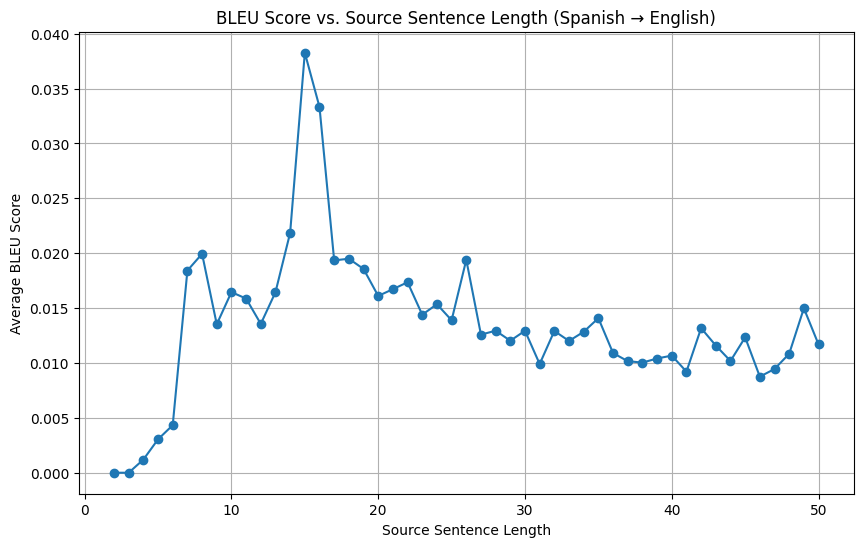

In [18]:
# Error Analysis: BLEU Score vs. Source Sentence Length (Spanish → English)

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from collections import defaultdict
import matplotlib.pyplot as plt
from transformers import BertTokenizer
import torch

# Constants
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")

# Decode token IDs to text
def decode_ids(ids):
    return tokenizer.decode(ids, skip_special_tokens=True)

# Compute sentence-level BLEU scores grouped by source sentence length
def compute_bleu_by_length(model, loader):
    model.eval()
    smoothing = SmoothingFunction().method1
    length_bleu = defaultdict(list)

    with torch.no_grad():
        for src_ids, src_mask, tgt_ids in loader:
            src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
            hidden = model.encoder(src_ids, src_mask)

            batch_size = src_ids.size(0)
            preds = torch.full((batch_size, 1), tokenizer.cls_token_id, dtype=torch.long).to(DEVICE)

            for _ in range(tgt_ids.size(1) - 1):
                out, hidden = model.decoder(preds, hidden)
                next_token = out[:, -1, :].argmax(dim=-1, keepdim=True)
                preds = torch.cat([preds, next_token], dim=1)

            for i in range(batch_size):
                ref = decode_ids(tgt_ids[i])
                hyp = decode_ids(preds[i])
                ref_tokens = [ref.split()]
                hyp_tokens = hyp.split()
                bleu = sentence_bleu(ref_tokens, hyp_tokens, smoothing_function=smoothing)
                src_len = (src_mask[i] != 0).sum().item()
                length_bleu[src_len].append(bleu)

    return length_bleu

# Run analysis
length_bleu = compute_bleu_by_length(model, test_loader)
bucket_bleu = {length: sum(scores)/len(scores) for length, scores in length_bleu.items()}
sorted_lengths = sorted(bucket_bleu.keys())
avg_bleus = [bucket_bleu[l] for l in sorted_lengths]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(sorted_lengths, avg_bleus, marker='o')
plt.xlabel("Source Sentence Length")
plt.ylabel("Average BLEU Score")
plt.title("BLEU Score vs. Source Sentence Length (Spanish → English)")
plt.grid(True)
plt.show()

In [ ]:
# same as spanish -> english. 
# high score: nothing, applause, parliament, the vote, short sentences, numbers
# low scores: wrong answers due to overfitting, i. e. applausos
df_test[["en", "es", "pred_es", "bleu"]].sort_values(by="bleu", ascending=False)

,en,es,pred_es,bleu
2609,.,.,.,1.0
15021,.,.,.,1.0
2946,.,.,.,1.0
1957,.,.,.,1.0
4258,.,.,.,1.0
...,...,...,...,...
9679,Customs 2000,«Aduana 2000»,La Sra . Maij - Weggen .,0.0
7026,,1.Desglose de los empleos a tiempo parcial por...,( Aplausos ),0.0
13101,The Commission can accept the following amendm...,La Comisión puede aceptar parcialmente las sig...,( Aplausos ),0.0
19392,Once again President Prodi: aux armes democrat...,"De nuevo reitero, señor Prodi: aux armes democ...",( Aplausos ),0.0


In [20]:
# Character-based Seq2Seq Model: English → Spanish

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from tqdm import tqdm

# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_CHAR_LEN = 100
BATCH_SIZE = 16
EMBED_DIM = 128
HIDDEN_DIM = 768
DROPOUT = 0.1
NUM_EPOCHS = 10
LR = 3e-4
TEACHER_FORCING_RATIO = 0.5

# Special tokens
PAD = "<pad>"
SOS = "<sos>"
EOS = "<eos>"
UNK = "<unk>"

def build_char_vocab(sentences, min_freq=1):
    counter = Counter()
    for s in sentences:
        counter.update(list(s))
    chars = [c for c, f in counter.items() if f >= min_freq]
    idx2char = [PAD, SOS, EOS, UNK] + sorted(chars)
    char2idx = {c: i for i, c in enumerate(idx2char)}
    return char2idx, idx2char

def encode_char_sequence(s, char2idx, max_len):
    chars = list(s)
    seq = [char2idx.get(SOS)]
    for c in chars:
        seq.append(char2idx.get(c, char2idx[UNK]))
        if len(seq) >= max_len - 1:
            break
    seq.append(char2idx.get(EOS))
    if len(seq) < max_len:
        seq += [char2idx.get(PAD)] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
        if seq[-1] != char2idx[EOS]:
            seq[-1] = char2idx[EOS]
    return torch.tensor(seq, dtype=torch.long)

class CharTranslationDataset(Dataset):
    def __init__(self, df_src, df_tgt, src_char2idx, tgt_char2idx, max_len):
        self.src_sentences = df_src.tolist()  # English
        self.tgt_sentences = df_tgt.tolist()  # Spanish
        self.src_char2idx = src_char2idx
        self.tgt_char2idx = tgt_char2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.src_sentences)

    def __getitem__(self, idx):
        src = self.src_sentences[idx]
        tgt = self.tgt_sentences[idx]
        src_seq = encode_char_sequence(src, self.src_char2idx, self.max_len)
        tgt_seq = encode_char_sequence(tgt, self.tgt_char2idx, self.max_len)
        return src_seq, tgt_seq

def collate_fn(batch):
    src_seqs, tgt_seqs = zip(*batch)
    src = torch.stack(src_seqs)
    tgt = torch.stack(tgt_seqs)
    return src, tgt

# Build vocabularies from training splits
src_sentences_train = df_train["en"].tolist()  # now source is English
tgt_sentences_train = df_train["es"].tolist()  # and target is Spanish
src_char2idx, src_idx2char = build_char_vocab(src_sentences_train)
tgt_char2idx, tgt_idx2char = build_char_vocab(tgt_sentences_train)

SRC_VOCAB_SIZE = len(src_idx2char)
TGT_VOCAB_SIZE = len(tgt_idx2char)

class Encoder(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embed_dim, padding_idx=src_char2idx[PAD])
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        return hidden

class Decoder(nn.Module):
    def __init__(self, output_dim, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, embed_dim, padding_idx=tgt_char2idx[PAD])
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_char, hidden):
        input_char = input_char.unsqueeze(1)
        embedded = self.dropout(self.embedding(input_char))
        output, hidden = self.rnn(embedded, hidden)
        pred = self.fc_out(output.squeeze(1))
        return pred, hidden

class Seq2SeqChar(nn.Module):
    def __init__(self, encoder, decoder, tgt_sos_idx, tgt_eos_idx, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.tgt_sos_idx = tgt_sos_idx
        self.tgt_eos_idx = tgt_eos_idx
        self.device = device

    def forward(self, src, tgt=None, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        max_len = tgt.size(1) if tgt is not None else MAX_CHAR_LEN
        outputs = torch.zeros(batch_size, max_len, TGT_VOCAB_SIZE, device=self.device)

        hidden = self.encoder(src)
        input_char = torch.full((batch_size,), self.tgt_sos_idx, dtype=torch.long, device=self.device)

        for t in range(0, max_len):
            pred, hidden = self.decoder(input_char, hidden)
            outputs[:, t, :] = pred
            use_teacher = (tgt is not None) and (torch.rand(1).item() < teacher_forcing_ratio)
            if use_teacher:
                input_char = tgt[:, t]
            else:
                input_char = pred.argmax(1)
        return outputs

# Instantiate datasets/loaders
train_ds_char = CharTranslationDataset(df_train["en"], df_train["es"], src_char2idx, tgt_char2idx, MAX_CHAR_LEN)
val_ds_char = CharTranslationDataset(df_val["en"], df_val["es"], src_char2idx, tgt_char2idx, MAX_CHAR_LEN)
test_ds_char = CharTranslationDataset(df_test["en"], df_test["es"], src_char2idx, tgt_char2idx, MAX_CHAR_LEN)

train_loader = DataLoader(train_ds_char, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds_char, batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(test_ds_char, batch_size=BATCH_SIZE, collate_fn=collate_fn)

# Model instantiation
encoder = Encoder(SRC_VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, DROPOUT)
decoder = Decoder(TGT_VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, DROPOUT)
model = Seq2SeqChar(encoder, decoder, tgt_sos_idx=tgt_char2idx[SOS], tgt_eos_idx=tgt_char2idx[EOS], device=DEVICE).to(DEVICE)

# Loss & optimizer
criterion = nn.CrossEntropyLoss(ignore_index=tgt_char2idx[PAD])
optimizer = optim.Adam(model.parameters(), lr=LR)

# Training / evaluation loops
def train_epoch(model, loader):
    model.train()
    epoch_loss = 0
    for src, tgt in tqdm(loader, desc="Train"):
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)
        optimizer.zero_grad()
        output = model(src, tgt, teacher_forcing_ratio=TEACHER_FORCING_RATIO)
        output_flat = output.reshape(-1, TGT_VOCAB_SIZE)
        tgt_flat = tgt.reshape(-1)
        loss = criterion(output_flat, tgt_flat)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)

def eval_epoch(model, loader):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src = src.to(DEVICE)
            tgt = tgt.to(DEVICE)
            output = model(src, tgt, teacher_forcing_ratio=0.0)
            loss = criterion(output.reshape(-1, TGT_VOCAB_SIZE), tgt.reshape(-1))
            epoch_loss += loss.item()
    return epoch_loss / len(loader)

# Run training
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader)
    val_loss = eval_epoch(model, val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Final test eval
test_loss = eval_epoch(model, test_loader)
print(f"\nTest Loss: {test_loss:.4f}")

# (Optional) Greedy inference
def translate_sentence_char(src_sentence, src_char2idx, tgt_idx2char, model, max_len=MAX_CHAR_LEN):
    model.eval()
    with torch.no_grad():
        src_seq = encode_char_sequence(src_sentence, src_char2idx, max_len).unsqueeze(0).to(DEVICE)
        output = model(src_seq, tgt=None, teacher_forcing_ratio=0.0)
        preds = output.argmax(-1).squeeze(0)
        result_chars = []
        for idx in preds:
            char = tgt_idx2char[idx.item()]
            if char == EOS:
                break
            if char not in {PAD, SOS}:
                result_chars.append(char)
        return "".join(result_chars)

Train: 100%|██████████| 860/860 [01:03<00:00, 13.57it/s]


Epoch 1 | Train Loss: 2.6255 | Val Loss: 3.0369


Train: 100%|██████████| 860/860 [01:03<00:00, 13.62it/s]


Epoch 2 | Train Loss: 2.4172 | Val Loss: 3.0069


Train: 100%|██████████| 860/860 [01:02<00:00, 13.69it/s]


...

Epoch 8 | Train Loss: 2.1749 | Val Loss: 3.4068


Train: 100%|██████████| 860/860 [01:02<00:00, 13.76it/s]


Epoch 9 | Train Loss: 2.1542 | Val Loss: 3.2474


Train: 100%|██████████| 860/860 [01:03<00:00, 13.57it/s]


Epoch 10 | Train Loss: 2.1400 | Val Loss: 3.2972

Test Loss: 3.2807


In [21]:
# Average BLEU score for character-level model (worse)

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Helpers: reference and hypothesis processing
def char_tokenize(s, keep_spaces=True):
    if not keep_spaces:
        s = s.replace(" ", "")
    return list(s.lower())

def word_tokenize_from_char_output(s):
    # simple whitespace split; you can refine (e.g., punctuation handling) if needed
    return s.lower().strip().split()

# Generate translations (greedy) from the char model
predictions_char = []
for sent in tqdm(df_test["es"], desc="Char-model translating"):  # Input is Spanish sentence now
    pred = translate_sentence_char(
        src_sentence=sent,  # Spanish sentence input
        src_char2idx=src_char2idx,
        tgt_idx2char=tgt_idx2char,
        model=model,
        max_len=MAX_CHAR_LEN,
    )
    predictions_char.append(pred)

df_test["pred_en_char"] = predictions_char  # Predicted English sentences

# Compute BLEU scores
smoothie = SmoothingFunction().method4

char_bleu_scores = []
word_bleu_scores = []

for ref, hyp in zip(df_test["en"], df_test["pred_en_char"]):  # References are English sentences now
    # Character-level BLEU (e.g., include spaces)
    ref_chars = char_tokenize(ref, keep_spaces=True)
    hyp_chars = char_tokenize(hyp, keep_spaces=True)
    cb_score = sentence_bleu([ref_chars], hyp_chars, weights=(0.25, 0.25, 0.25, 0.25),
                             smoothing_function=smoothie)
    char_bleu_scores.append(cb_score)

    # Word-level BLEU (from the character output)
    ref_words = word_tokenize_from_char_output(ref)
    hyp_words = word_tokenize_from_char_output(hyp)
    wb_score = sentence_bleu([ref_words], hyp_words, weights=(0.25, 0.25, 0.25, 0.25),
                             smoothing_function=smoothie)
    word_bleu_scores.append(wb_score)

df_test["bleu_char"] = char_bleu_scores
df_test["bleu_word_from_char"] = word_bleu_scores

avg_char_bleu = sum(char_bleu_scores) / len(char_bleu_scores)
avg_word_bleu = sum(word_bleu_scores) / len(word_bleu_scores)

print(f"Average character-level BLEU: {avg_char_bleu:.4f}")
print(f"Average word-level BLEU (from char output): {avg_word_bleu:.4f}")

Char-model translating: 100%|██████████| 3932/3932 [01:18<00:00, 49.91it/s]


Average character-level BLEU: 0.0492
Average word-level BLEU (from char output): 0.0066


In [4]:
# Spanish -> English: Word2Vec: 5.6672

import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from collections import defaultdict
import numpy as np
import gensim

# Hyperparameters
BATCH_SIZE = 64
EMBEDDING_DIM = 300
HIDDEN_SIZE = 512
NUM_EPOCHS = 10
MAX_LEN = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load or train Word2Vec model on combined text
combined_sentences = df_train["es"].tolist() + df_train["en"].tolist()
tokenized_sentences = [s.lower().split() for s in combined_sentences]
w2v_model = gensim.models.Word2Vec(sentences=tokenized_sentences, vector_size=EMBEDDING_DIM, window=5, min_count=1)

# Build vocab and embedding matrix
word2idx = defaultdict(lambda: 1, {"<pad>": 0, "<unk>": 1, "<sos>": 2, "<eos>": 3})
idx2word = {0: "<pad>", 1: "<unk>", 2: "<sos>", 3: "<eos>"}
embedding_matrix = [np.zeros(EMBEDDING_DIM), np.random.randn(EMBEDDING_DIM), np.random.randn(EMBEDDING_DIM), np.random.randn(EMBEDDING_DIM)]

for word in w2v_model.wv.index_to_key:
    idx = len(word2idx)
    word2idx[word] = idx
    idx2word[idx] = word
    embedding_matrix.append(w2v_model.wv[word])

embedding_matrix = np.stack(embedding_matrix)

# Dataset
class TranslationDataset(Dataset):
    def __init__(self, df, word2idx, max_len=MAX_LEN):
        self.src_sentences = df["es"].tolist()
        self.tgt_sentences = df["en"].tolist()
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.src_sentences)

    def tokenize_and_index(self, sentence):
        tokens = sentence.lower().split()
        ids = [self.word2idx.get(token, self.word2idx["<unk>"]) for token in tokens]
        return [self.word2idx["<sos>"]] + ids[:self.max_len - 2] + [self.word2idx["<eos>"]]

    def __getitem__(self, idx):
        src_ids = self.tokenize_and_index(self.src_sentences[idx])
        tgt_ids = self.tokenize_and_index(self.tgt_sentences[idx])
        return torch.tensor(src_ids), torch.tensor(tgt_ids)

def collate_fn(batch):
    src, tgt = zip(*batch)
    src = pad_sequence(src, padding_value=word2idx["<pad>"], batch_first=True)
    tgt = pad_sequence(tgt, padding_value=word2idx["<pad>"], batch_first=True)
    return src, tgt

# Seq2Seq Model
class Encoder(nn.Module):
    def __init__(self, embedding_matrix):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype=torch.float32), freeze=False)
        self.rnn = nn.GRU(embed_dim, HIDDEN_SIZE, batch_first=True)

    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.rnn(x)
        return hidden

class Decoder(nn.Module):
    def __init__(self, embedding_matrix):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype=torch.float32), freeze=False)
        self.rnn = nn.GRU(embed_dim, HIDDEN_SIZE, batch_first=True)
        self.fc = nn.Linear(HIDDEN_SIZE, vocab_size)

    def forward(self, x, hidden):
        x = self.embedding(x)
        output, hidden = self.rnn(x, hidden)
        return self.fc(output), hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        batch_size, tgt_len = tgt.size()
        outputs = torch.zeros(batch_size, tgt_len, len(word2idx)).to(DEVICE)
        hidden = self.encoder(src)
        input = tgt[:, 0].unsqueeze(1)

        for t in range(1, tgt_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t] = output.squeeze(1)
            input = tgt[:, t].unsqueeze(1)

        return outputs

# Prepare Datasets
train_dataset = TranslationDataset(df_train, word2idx)
val_dataset = TranslationDataset(df_val, word2idx)
test_dataset = TranslationDataset(df_test, word2idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)

# Instantiate Model
encoder = Encoder(embedding_matrix).to(DEVICE)
decoder = Decoder(embedding_matrix).to(DEVICE)
model = Seq2Seq(encoder, decoder).to(DEVICE)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss(ignore_index=word2idx["<pad>"])
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training and Evaluation
def train(model, loader):
    model.train()
    total_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        output = model(src, tgt)
        output = output[:, 1:].reshape(-1, len(word2idx))
        tgt = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            output = model(src, tgt)
            output = output[:, 1:].reshape(-1, len(word2idx))
            tgt = tgt[:, 1:].reshape(-1)
            loss = criterion(output, tgt)
            total_loss += loss.item()
    return total_loss / len(loader)

# Training Loop
for epoch in range(NUM_EPOCHS):
    train_loss = train(model, train_loader)
    val_loss = evaluate(model, val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Final Test Evaluation
test_loss = evaluate(model, test_loader)
print(f"\nTest Loss: {test_loss:.4f}")

KeyboardInterrupt: 

In [4]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import pandas as pd
from tqdm import tqdm
import torch

# Constants and mappings
MAX_LEN = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Function: Convert token indices back to sentence
def indices_to_sentence(indices):
    words = [idx2word.get(idx, "<unk>") for idx in indices]
    if "<eos>" in words:
        words = words[:words.index("<eos>")]
    return ' '.join(w for w in words if w not in {"<pad>", "<sos>", "<eos>"}).strip()

# Function: Translate single Spanish sentence to English (greedy decoding)
def translate_sentence(model, sentence, max_len=MAX_LEN):
    model.eval()
    with torch.no_grad():
        tokens = sentence.lower().split()
        src_ids = [word2idx["<sos>"]] + [word2idx.get(t, word2idx["<unk>"]) for t in tokens[:max_len - 2]] + [word2idx["<eos>"]]
        src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)
        hidden = model.encoder(src_tensor)

        input_token = torch.tensor([[word2idx["<sos>"]]]).to(DEVICE)
        output_sentence = []

        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)
            predicted_token = output.argmax(2)
            word_idx = predicted_token.item()
            if word_idx == word2idx["<eos>"]:
                break
            output_sentence.append(word_idx)
            input_token = predicted_token

    return indices_to_sentence(output_sentence)

# Translate test set from Spanish to English
predictions = []
for sent in tqdm(df_test["es"], desc="Translating"):
    prediction = translate_sentence(model, sent)
    predictions.append(prediction)

df_test["pred_en"] = predictions

# Compute BLEU score comparing prediction to true English
smoothie = SmoothingFunction().method4
bleu_scores = []
for ref, hyp in zip(df_test["en"], df_test["pred_en"]):
    ref_tokens = ref.lower().split()
    hyp_tokens = hyp.lower().split()
    score = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.5, 0.5), smoothing_function=smoothie)
    bleu_scores.append(score)

df_test["bleu"] = bleu_scores
avg_bleu = sum(bleu_scores) / len(bleu_scores)
print(f"\nAverage BLEU Score: {avg_bleu:.4f}")

df_test[["en", "es", "pred_en", "bleu"]]

Translating: 100%|██████████| 3932/3932 [01:18<00:00, 50.25it/s]



Average BLEU Score: 0.0786


,en,es,pred_en,bleu
12845,"(IT) Madam President, ladies and gentlemen, th...","(IT) Señora Presidenta, Señorías, éste no es s...","madam president, i would like to ask you to co...",0.131051
4546,"On the other hand, the concentration of high v...","Por otra parte, la concentración de jugadores ...",in the context of the world is the biggest phy...,0.142857
5927,I am saddened by some of the contributions thi...,Me siento afligido por algunas de las interven...,i have to say that i am very pleased to see my...,0.056344
5466,"Moreover, this resolution encourages Russia, a...","Además, esta resolución alienta a Rusia, como ...","in writing. - (pt) prespa park, and the prespa...",0.064820
14733,"However, I would like to make it abundantly cl...","No obstante, me gustaría dejar muy claro que n...",i do not believe that we are in the fact that ...,0.240099
...,...,...,...,...
18553,- (SV) If we had had the opportunity to devise...,. (SV) Si hubiésemos tenido la posibilidad de ...,i would like to ask you to thank the commissio...,0.072508
13809,The debate is closed.,El debate queda cerrado.,the debate is closed.,1.000000
1305,"For that reason, the Commission is right to fo...","Por esa razón, la Comisión tiene razón al cent...",the commission is also aware that the location...,0.131435
6373,The proposals put forward in the reports befor...,Las propuestas planteadas en los informes que ...,the strengths of multi-level governance must b...,0.068727


In [18]:
# Spanish -> English: GloVe

import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from collections import defaultdict
import numpy as np
import pandas as pd

# Hyperparameters
BATCH_SIZE = 64
EMBEDDING_DIM = 300
HIDDEN_SIZE = 512
NUM_EPOCHS = 10
MAX_LEN = 50
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load GloVe embeddings
glove_path = "glove.6B.300d.txt"
glove_embeddings = {}
with open(glove_path, encoding='utf-8') as f:
    for line in f:
        values = line.strip().split()
        word = values[0]
        vec = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = vec

# Build vocabulary
word2idx = defaultdict(lambda: 1, {"<pad>": 0, "<unk>": 1, "<sos>": 2, "<eos>": 3})
idx2word = {0: "<pad>", 1: "<unk>", 2: "<sos>", 3: "<eos>"}
embedding_matrix = [
    np.zeros(EMBEDDING_DIM),
    np.random.randn(EMBEDDING_DIM),
    np.random.randn(EMBEDDING_DIM),
    np.random.randn(EMBEDDING_DIM)
]

combined_sentences = df_train["es"].tolist() + df_train["en"].tolist()
tokens = set(w.lower() for s in combined_sentences for w in s.split())

for word in tokens:
    if word not in word2idx:
        idx = len(word2idx)
        word2idx[word] = idx
        idx2word[idx] = word
        vec = glove_embeddings.get(word)
        embedding_matrix.append(vec if vec is not None else np.random.randn(EMBEDDING_DIM))

embedding_matrix = np.stack(embedding_matrix)

# Dataset definition
class TranslationDataset(Dataset):
    def __init__(self, df, word2idx, max_len=MAX_LEN):
        self.src_sentences = df["es"].tolist()  # Spanish
        self.tgt_sentences = df["en"].tolist()  # English
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.src_sentences)

    def tokenize_and_index(self, sentence):
        tokens = sentence.lower().split()
        ids = [self.word2idx.get(token, self.word2idx["<unk>"]) for token in tokens]
        return [self.word2idx["<sos>"]] + ids[:self.max_len - 2] + [self.word2idx["<eos>"]]

    def __getitem__(self, idx):
        src_ids = self.tokenize_and_index(self.src_sentences[idx])
        tgt_ids = self.tokenize_and_index(self.tgt_sentences[idx])
        return torch.tensor(src_ids), torch.tensor(tgt_ids)

def collate_fn(batch):
    src, tgt = zip(*batch)
    src = pad_sequence(src, padding_value=word2idx["<pad>"], batch_first=True)
    tgt = pad_sequence(tgt, padding_value=word2idx["<pad>"], batch_first=True)
    return src, tgt

# Seq2Seq Model definition
class Encoder(nn.Module):
    def __init__(self, embedding_matrix):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype=torch.float32), freeze=False)
        self.rnn = nn.GRU(embed_dim, HIDDEN_SIZE, batch_first=True)

    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.rnn(x)
        return hidden

class Decoder(nn.Module):
    def __init__(self, embedding_matrix):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype=torch.float32), freeze=False)
        self.rnn = nn.GRU(embed_dim, HIDDEN_SIZE, batch_first=True)
        self.fc = nn.Linear(HIDDEN_SIZE, vocab_size)

    def forward(self, x, hidden):
        x = self.embedding(x)
        output, hidden = self.rnn(x, hidden)
        return self.fc(output), hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt):
        batch_size, tgt_len = tgt.size()
        outputs = torch.zeros(batch_size, tgt_len, len(word2idx)).to(DEVICE)
        hidden = self.encoder(src)
        input = tgt[:, 0].unsqueeze(1)
        for t in range(1, tgt_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t] = output.squeeze(1)
            input = tgt[:, t].unsqueeze(1)
        return outputs

# Prepare Dataloaders
train_dataset = TranslationDataset(df_train, word2idx)
val_dataset = TranslationDataset(df_val, word2idx)
test_dataset = TranslationDataset(df_test, word2idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn)

# Model, loss, optimizer
encoder = Encoder(embedding_matrix).to(DEVICE)
decoder = Decoder(embedding_matrix).to(DEVICE)
model = Seq2Seq(encoder, decoder).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=word2idx["<pad>"])
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training and evaluation loops
def train(model, loader):
    model.train()
    total_loss = 0
    for src, tgt in tqdm(loader, desc="Training"):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        output = model(src, tgt)
        output = output[:, 1:].reshape(-1, len(word2idx))
        tgt = tgt[:, 1:].reshape(-1)
        loss = criterion(output, tgt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            output = model(src, tgt)
            output = output[:, 1:].reshape(-1, len(word2idx))
            tgt = tgt[:, 1:].reshape(-1)
            loss = criterion(output, tgt)
            total_loss += loss.item()
    return total_loss / len(loader)

# Run training
for epoch in range(NUM_EPOCHS):
    train_loss = train(model, train_loader)
    val_loss = evaluate(model, val_loader)
    print(f"Epoch {epoch + 1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Final test loss
test_loss = evaluate(model, test_loader)
print(f"\nTest Loss: {test_loss:.4f}")

Training: 100%|██████████| 215/215 [02:04<00:00,  1.73it/s]


Epoch 1 | Train Loss: 6.6387 | Val Loss: 5.9175


Training: 100%|██████████| 215/215 [02:04<00:00,  1.73it/s]


Epoch 2 | Train Loss: 5.4970 | Val Loss: 5.4503


Training: 100%|██████████| 215/215 [02:04<00:00,  1.73it/s]


...

Epoch 8 | Train Loss: 2.6220 | Val Loss: 5.2432


Training: 100%|██████████| 215/215 [02:03<00:00,  1.74it/s]


Epoch 9 | Train Loss: 2.2900 | Val Loss: 5.3405


Training: 100%|██████████| 215/215 [02:03<00:00,  1.74it/s]


Epoch 10 | Train Loss: 1.9988 | Val Loss: 5.4578

Test Loss: 5.4302


In [19]:
import torch
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from tqdm import tqdm

# Convert indices to sentence (remove special tokens)
def indices_to_sentence(indices, idx2word):
    words = [idx2word.get(idx, "<unk>") for idx in indices]
    if "<eos>" in words:
        words = words[:words.index("<eos>")]
    return ' '.join(w for w in words if w not in {"<pad>", "<sos>", "<eos>"}).strip()

# Greedy decoding for a single Spanish sentence → English
def translate_sentence(model, sentence, word2idx, idx2word, max_len, device):
    model.eval()
    with torch.no_grad():
        tokens = sentence.lower().split()
        src_ids = [word2idx["<sos>"]] + [word2idx.get(t, word2idx["<unk>"]) for t in tokens[:max_len - 2]] + [word2idx["<eos>"]]
        src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)
        hidden = model.encoder(src_tensor)

        input_token = torch.tensor([[word2idx["<sos>"]]], dtype=torch.long).to(device)
        output_sentence = []

        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)
            predicted_token = output.argmax(2)
            word_idx = predicted_token.item()
            if word_idx == word2idx["<eos>"]:
                break
            output_sentence.append(word_idx)
            input_token = predicted_token

    return indices_to_sentence(output_sentence, idx2word)

# Generate translations for the test set (Spanish → English)
predictions = []
for sent in tqdm(df_test["es"], desc="Translating"):
    pred = translate_sentence(
        model=model,
        sentence=sent,
        word2idx=word2idx,
        idx2word=idx2word,
        max_len=MAX_LEN,
        device=DEVICE
    )
    predictions.append(pred)

df_test["pred_en"] = predictions

# Compute BLEU score
smoothie = SmoothingFunction().method4
bleu_scores = []
for ref, hyp in zip(df_test["en"], df_test["pred_en"]):
    ref_tokens = ref.lower().split()
    hyp_tokens = hyp.lower().split()
    score = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.5, 0.5), smoothing_function=smoothie)
    bleu_scores.append(score)

df_test["bleu"] = bleu_scores
avg_bleu = sum(bleu_scores) / len(bleu_scores)
print(f"\nAverage BLEU Score (Spanish → English): {avg_bleu:.4f}")

df_test[["en", "es", "pred_en", "bleu"]]

Translating: 100%|██████████| 3932/3932 [01:21<00:00, 47.97it/s]



Average BLEU Score (Spanish → English): 0.0802


,en,es,pred_en,bleu
12845,"(IT) Madam President, ladies and gentlemen, th...","(IT) Señora Presidenta, Señorías, éste no es s...","(it) madam president, ladies and gentlemen, we...",0.120736
4546,"On the other hand, the concentration of high v...","Por otra parte, la concentración de jugadores ...","furthermore, the seychelles fishing sector is ...",0.045106
5927,I am saddened by some of the contributions thi...,Me siento afligido por algunas de las interven...,i am sure that this will now be a priority of ...,0.052617
5466,"Moreover, this resolution encourages Russia, a...","Además, esta resolución alienta a Rusia, como ...",this resolution resolution contains a resoluti...,0.145686
14733,"However, I would like to make it abundantly cl...","No obstante, me gustaría dejar muy claro que n...",i would like to ask you for this report that i...,0.205269
...,...,...,...,...
18553,- (SV) If we had had the opportunity to devise...,. (SV) Si hubiésemos tenido la posibilidad de ...,"if, when we had had the opportunity to speak a...",0.215131
13809,The debate is closed.,El debate queda cerrado.,the debate is closed.,1.000000
1305,"For that reason, the Commission is right to fo...","Por esa razón, la Comisión tiene razón al cent...","that is why the commission is responsible, and...",0.121685
6373,The proposals put forward in the reports befor...,Las propuestas planteadas en los informes que ...,"the proposals are excellent, and, in particula...",0.078087


In [20]:
# Spanish -> English: mBERT

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer
from tqdm import tqdm

# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 50
BATCH_SIZE = 16
HIDDEN_SIZE = 512
NUM_EPOCHS = 10
LR = 1e-3

# Load mBERT model & tokenizer
bert_model = BertModel.from_pretrained("bert-base-multilingual-cased").to(DEVICE)
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")

# Spanish -> English Dataset
class TranslationDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.src_sentences = df["es"].tolist()  # Spanish input
        self.tgt_sentences = df["en"].tolist()  # English target
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.src_sentences)

    def __getitem__(self, idx):
        src = self.src_sentences[idx]
        tgt = self.tgt_sentences[idx]

        src_enc = self.tokenizer(src, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")
        tgt_enc = self.tokenizer(tgt, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")

        return src_enc["input_ids"].squeeze(0), src_enc["attention_mask"].squeeze(0), tgt_enc["input_ids"].squeeze(0)

def collate_fn(batch):
    src_ids, src_mask, tgt_ids = zip(*batch)
    return torch.stack(src_ids), torch.stack(src_mask), torch.stack(tgt_ids)

# Encoder (frozen BERT + projection layer)
class BertEncoder(nn.Module):
    def __init__(self, bert_model, hidden_size):
        super().__init__()
        self.bert = bert_model
        self.proj = nn.Linear(bert_model.config.hidden_size, hidden_size)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        projected = self.proj(cls_output)
        return projected.unsqueeze(0)

# Decoder: GRU-based
class Decoder(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, HIDDEN_SIZE)
        self.rnn = nn.GRU(HIDDEN_SIZE, HIDDEN_SIZE, batch_first=True)
        self.fc = nn.Linear(HIDDEN_SIZE, vocab_size)

    def forward(self, tgt, hidden):
        embedded = self.embedding(tgt)
        output, hidden = self.rnn(embedded, hidden)
        return self.fc(output), hidden

# Seq2Seq Wrapper
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src_ids, src_mask, tgt):
        hidden = self.encoder(src_ids, src_mask)
        output, _ = self.decoder(tgt[:, :-1], hidden)
        return output

# Prepare datasets and loaders
train_ds = TranslationDataset(df_train, tokenizer, MAX_LEN)
val_ds = TranslationDataset(df_val, tokenizer, MAX_LEN)
test_ds = TranslationDataset(df_test, tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)

# Instantiate model, criterion, optimizer
encoder = BertEncoder(bert_model, HIDDEN_SIZE)
decoder = Decoder(tokenizer.vocab_size)
model = Seq2Seq(encoder, decoder).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
optimizer = optim.Adam(model.decoder.parameters(), lr=LR)

# Training loop
def train(model, loader):
    model.train()
    total_loss = 0
    for src_ids, src_mask, tgt_ids in tqdm(loader, desc="Training"):
        src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
        output = model(src_ids, src_mask, tgt_ids)
        loss = criterion(output.reshape(-1, tokenizer.vocab_size), tgt_ids[:, 1:].reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Evaluation loop
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src_ids, src_mask, tgt_ids in loader:
            src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
            output = model(src_ids, src_mask, tgt_ids)
            loss = criterion(output.reshape(-1, tokenizer.vocab_size), tgt_ids[:, 1:].reshape(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

# Run training
for epoch in range(NUM_EPOCHS):
    train_loss = train(model, train_loader)
    val_loss = evaluate(model, val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Final test evaluation
test_loss = evaluate(model, test_loader)
print(f"\nTest Loss: {test_loss:.4f}")

Training: 100%|██████████| 860/860 [01:33<00:00,  9.21it/s]


Epoch 1 | Train Loss: 5.4336 | Val Loss: 4.7302


Training: 100%|██████████| 860/860 [01:33<00:00,  9.21it/s]


Epoch 2 | Train Loss: 4.2088 | Val Loss: 4.4848


Training: 100%|██████████| 860/860 [01:33<00:00,  9.20it/s]


...

Epoch 8 | Train Loss: 1.8240 | Val Loss: 5.0869


Training: 100%|██████████| 860/860 [01:33<00:00,  9.21it/s]


Epoch 9 | Train Loss: 1.6200 | Val Loss: 5.2780


Training: 100%|██████████| 860/860 [01:33<00:00,  9.21it/s]


Epoch 10 | Train Loss: 1.4515 | Val Loss: 5.4534

Test Loss: 5.4288


In [21]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from transformers import BertTokenizer
import torch
from tqdm import tqdm
import pandas as pd

# Constants
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 50

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")
sos_token_id = tokenizer.convert_tokens_to_ids("[CLS]")
eos_token_id = tokenizer.convert_tokens_to_ids("[SEP]")
pad_token_id = tokenizer.pad_token_id

# Decode token IDs to sentence
def decode_ids(ids):
    tokens = tokenizer.convert_ids_to_tokens(ids, skip_special_tokens=True)
    return tokenizer.convert_tokens_to_string(tokens).strip()

# Translate Spanish → English using greedy decoding
def translate_sentence(model, sentence, max_len=MAX_LEN):
    model.eval()
    with torch.no_grad():
        encoded = tokenizer(sentence, return_tensors="pt", truncation=True, padding="max_length", max_length=max_len)
        src_ids = encoded["input_ids"].to(DEVICE)
        src_mask = encoded["attention_mask"].to(DEVICE)

        hidden = model.encoder(src_ids, src_mask)
        input_token = torch.tensor([[sos_token_id]]).to(DEVICE)
        output_ids = []

        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)
            next_token_id = output.argmax(2).item()
            if next_token_id == eos_token_id:
                break
            output_ids.append(next_token_id)
            input_token = torch.tensor([[next_token_id]]).to(DEVICE)

        return decode_ids(output_ids)

# Generate translations for the test set (Spanish → English)
predictions = []
for sent in tqdm(df_test["es"], desc="Translating"):
    pred = translate_sentence(model, sent)
    predictions.append(pred)

df_test["pred_en"] = predictions

# Compute BLEU scores
smoothie = SmoothingFunction().method4
bleu_scores = []

for ref, hyp in zip(df_test["en"], df_test["pred_en"]):
    ref_tokens = tokenizer.tokenize(ref.lower())
    hyp_tokens = tokenizer.tokenize(hyp.lower())
    score = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.5, 0.5), smoothing_function=smoothie)
    bleu_scores.append(score)

df_test["bleu"] = bleu_scores
avg_bleu = sum(bleu_scores) / len(bleu_scores)
print(f"\nAverage BLEU Score: {avg_bleu:.4f}")

df_test[["en", "es", "pred_en", "bleu"]]

Translating: 100%|██████████| 3932/3932 [02:00<00:00, 32.76it/s]



Average BLEU Score: 0.0818


,en,es,pred_en,bleu
12845,"(IT) Madam President, ladies and gentlemen, th...","(IT) Señora Presidenta, Señorías, éste no es s...","( DE ) Madam President , Commissioner , ladies...",0.100128
4546,"On the other hand, the concentration of high v...","Por otra parte, la concentración de jugadores ...",The importance of integrating vulnerable peopl...,0.130822
5927,I am saddened by some of the contributions thi...,Me siento afligido por algunas de las interven...,I would like to thank Dr Adam for this report .,0.069141
5466,"Moreover, this resolution encourages Russia, a...","Además, esta resolución alienta a Rusia, como ...",The European Union and the United Nations Comm...,0.140346
14733,"However, I would like to make it abundantly cl...","No obstante, me gustaría dejar muy claro que n...","We are in favour of the European Union , but w...",0.111208
...,...,...,...,...
18553,- (SV) If we had had the opportunity to devise...,. (SV) Si hubiésemos tenido la posibilidad de ...,The second is sanction mechanisms against thos...,0.028257
13809,The debate is closed.,El debate queda cerrado.,The debate is closed .,1.000000
1305,"For that reason, the Commission is right to fo...","Por esa razón, la Comisión tiene razón al cent...","We are in favour of a European identity , and ...",0.143833
6373,The proposals put forward in the reports befor...,Las propuestas planteadas en los informes que ...,The European Union and the United Nations Comm...,0.031559


In [22]:
# Preprocessing Impact Evaluation

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer
from tqdm import tqdm
from copy import deepcopy
from sklearn.model_selection import train_test_split
import gc
import nltk
nltk.download('punkt')

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 50
BATCH_SIZE = 16
HIDDEN_SIZE = 512
NUM_EPOCHS = 5

bert_model = BertModel.from_pretrained("bert-base-multilingual-cased").to(DEVICE)
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")
sos_token_id = tokenizer.convert_tokens_to_ids("[CLS]")
eos_token_id = tokenizer.convert_tokens_to_ids("[SEP]")
pad_token_id = tokenizer.pad_token_id

# Dataset class for Spanish -> English translation
class TranslationDataset(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.src_sentences = df["es"].tolist()  # Source: Spanish
        self.tgt_sentences = df["en"].tolist()  # Target: English
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.src_sentences)

    def __getitem__(self, idx):
        src = self.src_sentences[idx]
        tgt = self.tgt_sentences[idx]

        enc = self.tokenizer(src, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")
        dec = self.tokenizer(tgt, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")

        return enc["input_ids"].squeeze(0), enc["attention_mask"].squeeze(0), dec["input_ids"].squeeze(0)

def collate_fn(batch):
    src_ids, src_mask, tgt_ids = zip(*batch)
    return torch.stack(src_ids), torch.stack(src_mask), torch.stack(tgt_ids)

# Encoder with frozen BERT
class BertEncoder(nn.Module):
    def __init__(self, bert_model, hidden_size):
        super().__init__()
        self.bert = bert_model
        self.proj = nn.Linear(bert_model.config.hidden_size, hidden_size)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # CLS token output
        projected = self.proj(cls_output)
        return projected.unsqueeze(0)  # (1, batch_size, hidden_size)

# Decoder with GRU
class Decoder(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, HIDDEN_SIZE)
        self.rnn = nn.GRU(HIDDEN_SIZE, HIDDEN_SIZE, batch_first=True)
        self.fc = nn.Linear(HIDDEN_SIZE, vocab_size)

    def forward(self, tgt, hidden):
        embedded = self.embedding(tgt)
        output, hidden = self.rnn(embedded, hidden)
        return self.fc(output), hidden

# Seq2Seq model
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src_ids, src_mask, tgt):
        hidden = self.encoder(src_ids, src_mask)
        outputs, _ = self.decoder(tgt[:, :-1], hidden)
        return outputs

def decode_ids(ids):
    tokens = tokenizer.convert_ids_to_tokens(ids, skip_special_tokens=True)
    return tokenizer.convert_tokens_to_string(tokens).strip()

def translate_sentence(model, sentence, max_len=MAX_LEN):
    model.eval()
    with torch.no_grad():
        encoded = tokenizer(sentence, return_tensors="pt", truncation=True, padding="max_length", max_length=max_len)
        src_ids = encoded["input_ids"].to(DEVICE)
        src_mask = encoded["attention_mask"].to(DEVICE)

        hidden = model.encoder(src_ids, src_mask)
        input_token = torch.tensor([[sos_token_id]]).to(DEVICE)
        output_ids = []

        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)
            next_token_id = output.argmax(2).item()
            if next_token_id == eos_token_id:
                break
            output_ids.append(next_token_id)
            input_token = torch.tensor([[next_token_id]]).to(DEVICE)

        return decode_ids(output_ids)

def benchmark_bleu(df):
    # Split data (80% train+val, 20% test)
    df_trainval, df_test = train_test_split(df, test_size=0.2, random_state=42)
    # Split train+val further (train: 70%, val: 10%)
    df_train, df_val = train_test_split(df_trainval, test_size=0.125, random_state=42)

    train_ds = TranslationDataset(df_train, tokenizer, MAX_LEN)
    val_ds = TranslationDataset(df_val, tokenizer, MAX_LEN)
    test_ds = TranslationDataset(df_test, tokenizer, MAX_LEN)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)

    encoder = BertEncoder(bert_model, HIDDEN_SIZE)
    decoder = Decoder(tokenizer.vocab_size)
    model = Seq2Seq(encoder, decoder).to(DEVICE)

    optimizer = optim.Adam(model.decoder.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)

    def train(model, loader):
        model.train()
        total_loss = 0
        for src_ids, src_mask, tgt_ids in tqdm(loader, desc="Training", disable=True):
            src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
            output = model(src_ids, src_mask, tgt_ids)
            loss = criterion(output.reshape(-1, tokenizer.vocab_size), tgt_ids[:, 1:].reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(loader)

    def evaluate(model, loader):
        model.eval()
        total_loss = 0
        with torch.no_grad():
            for src_ids, src_mask, tgt_ids in loader:
                src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
                output = model(src_ids, src_mask, tgt_ids)
                loss = criterion(output.reshape(-1, tokenizer.vocab_size), tgt_ids[:, 1:].reshape(-1))
                total_loss += loss.item()
        return total_loss / len(loader)

    for epoch in range(NUM_EPOCHS):
        train(model, train_loader)
        evaluate(model, test_loader)

    predictions = []
    for sent in tqdm(df_test["es"], desc="Translating", disable=True):  # Source: Spanish
        pred = translate_sentence(model, sent)
        predictions.append(pred)
    df_test["pred_en"] = predictions  # Predicted English sentences

    smoothie = SmoothingFunction().method4
    bleu_scores = []
    for ref, hyp in zip(df_test["en"], df_test["pred_en"]):  # Reference is English
        ref_tokens = tokenizer.tokenize(ref.lower())
        hyp_tokens = tokenizer.tokenize(hyp.lower())
        score = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.5, 0.5), smoothing_function=smoothie)
        bleu_scores.append(score)

    del model, encoder, decoder, optimizer, criterion
    torch.cuda.empty_cache()
    gc.collect()

    return sum(bleu_scores) / len(bleu_scores)

# Preprocessing options remain the same
options = [
    "lowercase",
    "expand_contractions",
    "remove_urls",
    "remove_non_ascii",
    "strip_multispace",
    "unicode_normalization",
    "remove_xml_lines",
    "language_check",
    "sentence_segmentation",
]

df_base = deepcopy(df)

print("⏳ Calculating baseline BLEU...")
bleu_base = benchmark_bleu(df_base)
print(f"\n{'Baseline BLEU':25s}: {bleu_base:.4f}")
print(f"{'Preprocessing Option':25s} | {'Δ BLEU'}")
print("-" * 50)

for opt in options:
    kwargs = {k: False for k in options}
    kwargs[opt] = True
    kwargs["expected_lang"] = "es"  # Source is Spanish now
    kwargs["overwrite_column"] = "es"  # Preprocess Spanish column

    df_opt = preprocessing(deepcopy(df), "es", **kwargs)
    df_opt.dropna(inplace=True)

    bleu = benchmark_bleu(df_opt)
    delta = bleu - bleu_base
    print(f"{opt:25s} | {delta:+.4f}")

    del df_opt, bleu
    gc.collect()

[nltk_data] Downloading package punkt to /home/max/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


⏳ Calculating baseline BLEU...

Baseline BLEU            : 0.0739
Preprocessing Option      | Δ BLEU
--------------------------------------------------
lowercase                 | +0.0057
expand_contractions       | +0.0021
remove_urls               | +0.0059
remove_non_ascii          | -0.0041
strip_multispace          | -0.0039
unicode_normalization     | +0.0035
remove_xml_lines          | -0.0089
language_check            | -0.0010
sentence_segmentation     | +0.0040


In [3]:
# HPO with mBERT encoder: Spanish → English

import torch
import torch.nn as nn
import torch.optim as optim
from transformers import BertModel, BertTokenizer
from torch.utils.data import DataLoader, TensorDataset
from copy import deepcopy
import itertools

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = 20
BATCH_SIZE = 32

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")
sos_token_id = tokenizer.convert_tokens_to_ids("[CLS]")
eos_token_id = tokenizer.convert_tokens_to_ids("[SEP]")
pad_token_id = tokenizer.pad_token_id
VOCAB_SIZE = tokenizer.vocab_size

# Tokenize and encode
def encode_sentences(src_texts, tgt_texts, tokenizer, seq_len):
    src_encodings = tokenizer(src_texts, padding='max_length', truncation=True, max_length=seq_len, return_tensors="pt")
    tgt_encodings = tokenizer(tgt_texts, padding='max_length', truncation=True, max_length=seq_len, return_tensors="pt")
    return src_encodings['input_ids'], src_encodings['attention_mask'], tgt_encodings['input_ids']

train_src_ids, train_src_mask, train_tgt_ids = encode_sentences(df_train["es"].tolist(), df_train["en"].tolist(), tokenizer, SEQ_LEN)
val_src_ids, val_src_mask, val_tgt_ids = encode_sentences(df_val["es"].tolist(), df_val["en"].tolist(), tokenizer, SEQ_LEN)


# Create DataLoaders
train_dataset = TensorDataset(train_src_ids, train_src_mask, train_tgt_ids)
val_dataset = TensorDataset(val_src_ids, val_src_mask, val_tgt_ids)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Encoder using mBERT
class MBertEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-multilingual-cased")
    
    def forward(self, src_ids, src_mask):
        outputs = self.bert(input_ids=src_ids, attention_mask=src_mask)
        pooled = outputs.last_hidden_state[:, 0].unsqueeze(0)  # [1, batch, hidden]
        return pooled

# Decoder
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, hidden):
        embedded = self.dropout(self.embedding(tgt))
        out, hidden = self.rnn(embedded, hidden.contiguous())
        return self.fc(out), hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, src_mask, tgt):
        hidden = self.encoder(src, src_mask)  # from BERT
        output, _ = self.decoder(tgt[:, :-1], hidden)
        return output

# Train and eval functions
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for src_ids, src_mask, tgt_ids in loader:
        src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
        output = model(src_ids, src_mask, tgt_ids)
        loss = criterion(output.reshape(-1, VOCAB_SIZE), tgt_ids[:, 1:].reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src_ids, src_mask, tgt_ids in loader:
            src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
            output = model(src_ids, src_mask, tgt_ids)
            loss = criterion(output.reshape(-1, VOCAB_SIZE), tgt_ids[:, 1:].reshape(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

# Hyperparameter grid
search_space = {
    "embed_dim": [768], #, 256, 512],
    "hidden_dim": [768], #, 512, 1024],
    "dropout": [0.3], #, 0.5, 0.1],
    "lr": [3e-4],  #, 5e-5, 1e-4],
}

best_val_loss = float("inf")
best_config = None
best_model = None

# Random/Grid Search
for embed_dim, hidden_dim, dropout, lr in itertools.product(
    search_space["embed_dim"],
    search_space["hidden_dim"],
    search_space["dropout"],
    search_space["lr"]
):
    print(f"\nTrying: embed_dim={embed_dim}, hidden_dim={hidden_dim}, dropout={dropout}, lr={lr}")
    
    encoder = MBertEncoder().to(DEVICE)
    decoder = Decoder(VOCAB_SIZE, embed_dim, hidden_dim, dropout).to(DEVICE)
    model = Seq2Seq(encoder, decoder).to(DEVICE)

    optimizer = optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=pad_token_id)

    train_loss = train(model, train_loader, optimizer, criterion)
    val_loss = evaluate(model, val_loader, criterion)
    print(f"Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_config = {
            "embed_dim": embed_dim,
            "hidden_dim": hidden_dim,
            "dropout": dropout,
            "lr": lr,
        }
        best_model = deepcopy(model)

print("\n✅ Best config:", best_config)
print(f"✅ Best validation loss: {best_val_loss:.4f}")

/home/max/.cache/pypoetry/virtualenvs/nlp-2025-4ec33wE2-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Trying: embed_dim=768, hidden_dim=768, dropout=0.3, lr=0.0003
Train loss: 6.0039, Val loss: 5.2785

✅ Best config: {'embed_dim': 768, 'hidden_dim': 768, 'dropout': 0.3, 'lr': 0.0003}
✅ Best validation loss: 5.2785


In [ ]:
# Spanish -> English final model: mBERT, no preprocessing, optimized HPs: {'embed_dim': 128, 'hidden_dim': 768, 'dropout': 0.1, 'lr': 0.0003}

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer
from tqdm import tqdm

# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 50
BATCH_SIZE = 16
EMBED_DIM = 768
HIDDEN_DIM = 768
DROPOUT = 0.1
NUM_EPOCHS = 10
LR = 3e-4

# Load mBERT model & tokenizer
bert_model = BertModel.from_pretrained("bert-base-multilingual-cased").to(DEVICE)
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")

# Spanish → English Dataset
class TranslationDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.src_sentences = df["es"].tolist()  # Spanish input
        self.tgt_sentences = df["en"].tolist()  # English target
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.src_sentences)

    def __getitem__(self, idx):
        src = self.src_sentences[idx]
        tgt = self.tgt_sentences[idx]

        src_enc = self.tokenizer(src, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")
        tgt_enc = self.tokenizer(tgt, truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")

        return src_enc["input_ids"].squeeze(0), src_enc["attention_mask"].squeeze(0), tgt_enc["input_ids"].squeeze(0)

def collate_fn(batch):
    src_ids, src_mask, tgt_ids = zip(*batch)
    return torch.stack(src_ids), torch.stack(src_mask), torch.stack(tgt_ids)

# Encoder (frozen BERT + projection layer)
class BertEncoder(nn.Module):
    def __init__(self, bert_model, hidden_size):
        super().__init__()
        self.bert = bert_model
        self.proj = nn.Linear(bert_model.config.hidden_size, hidden_size)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        projected = self.proj(cls_output)
        return projected.unsqueeze(0)

# Decoder: GRU-based
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, hidden):
        embedded = self.dropout(self.embedding(tgt))
        output, hidden = self.rnn(embedded, hidden)
        return self.fc(output), hidden

# Seq2Seq Wrapper
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src_ids, src_mask, tgt):
        hidden = self.encoder(src_ids, src_mask)
        output, _ = self.decoder(tgt[:, :-1], hidden)
        return output

# Prepare datasets and loaders
train_ds = TranslationDataset(df_train, tokenizer, MAX_LEN)
val_ds = TranslationDataset(df_val, tokenizer, MAX_LEN)
test_ds = TranslationDataset(df_test, tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)

# Instantiate model, criterion, optimizer
encoder = BertEncoder(bert_model, HIDDEN_DIM)
decoder = Decoder(tokenizer.vocab_size, EMBED_DIM, HIDDEN_DIM, DROPOUT)
model = Seq2Seq(encoder, decoder).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
optimizer = optim.Adam(model.decoder.parameters(), lr=LR)

# Training loop
def train(model, loader):
    model.train()
    total_loss = 0
    for src_ids, src_mask, tgt_ids in tqdm(loader, desc="Training"):
        src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
        output = model(src_ids, src_mask, tgt_ids)
        loss = criterion(output.reshape(-1, tokenizer.vocab_size), tgt_ids[:, 1:].reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Evaluation loop
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src_ids, src_mask, tgt_ids in loader:
            src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
            output = model(src_ids, src_mask, tgt_ids)
            loss = criterion(output.reshape(-1, tokenizer.vocab_size), tgt_ids[:, 1:].reshape(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

# Run training
for epoch in range(NUM_EPOCHS):
    train_loss = train(model, train_loader)
    val_loss = evaluate(model, val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Final test evaluation
test_loss = evaluate(model, test_loader)
print(f"\nTest Loss: {test_loss:.4f}")


Training: 100%|██████████| 860/860 [01:59<00:00,  7.22it/s]


Epoch 1 | Train Loss: 5.8295 | Val Loss: 5.1028


Training: 100%|██████████| 860/860 [01:59<00:00,  7.20it/s]


Epoch 2 | Train Loss: 4.7559 | Val Loss: 4.7365


Training: 100%|██████████| 860/860 [01:59<00:00,  7.20it/s]


...

Epoch 8 | Train Loss: 3.1967 | Val Loss: 4.4384


Training: 100%|██████████| 860/860 [01:59<00:00,  7.19it/s]


Epoch 9 | Train Loss: 3.0486 | Val Loss: 4.4567


Training: 100%|██████████| 860/860 [01:59<00:00,  7.19it/s]


Epoch 10 | Train Loss: 2.9126 | Val Loss: 4.4843

Test Loss: 4.4679


In [13]:
# Calculate average BLEU

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from transformers import BertTokenizer
import torch
from tqdm import tqdm
import pandas as pd

# Constants
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 50

# Load tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")
sos_token_id = tokenizer.convert_tokens_to_ids("[CLS]")
eos_token_id = tokenizer.convert_tokens_to_ids("[SEP]")
pad_token_id = tokenizer.pad_token_id

# Decode token IDs to sentence
def decode_ids(ids):
    tokens = tokenizer.convert_ids_to_tokens(ids, skip_special_tokens=True)
    return tokenizer.convert_tokens_to_string(tokens).strip()

# Translate Spanish → English using greedy decoding
def translate_sentence(model, sentence, max_len=MAX_LEN):
    model.eval()
    with torch.no_grad():
        encoded = tokenizer(sentence, return_tensors="pt", truncation=True, padding="max_length", max_length=max_len)
        src_ids = encoded["input_ids"].to(DEVICE)
        src_mask = encoded["attention_mask"].to(DEVICE)

        hidden = model.encoder(src_ids, src_mask)
        input_token = torch.tensor([[sos_token_id]]).to(DEVICE)
        output_ids = []

        for _ in range(max_len):
            output, hidden = model.decoder(input_token, hidden)
            next_token_id = output.argmax(2).item()
            if next_token_id == eos_token_id:
                break
            output_ids.append(next_token_id)
            input_token = torch.tensor([[next_token_id]]).to(DEVICE)

        return decode_ids(output_ids)

# Generate translations for the test set (Spanish → English)
predictions = []
for sent in tqdm(df_test["es"], desc="Translating"):
    pred = translate_sentence(model, sent)
    predictions.append(pred)

df_test["pred_en"] = predictions

# Compute BLEU scores
smoothie = SmoothingFunction().method4
bleu_scores = []

for ref, hyp in zip(df_test["en"], df_test["pred_en"]):
    ref_tokens = tokenizer.tokenize(ref.lower())
    hyp_tokens = tokenizer.tokenize(hyp.lower())
    score = sentence_bleu([ref_tokens], hyp_tokens, weights=(0.5, 0.5), smoothing_function=smoothie)
    bleu_scores.append(score)

df_test["bleu"] = bleu_scores
avg_bleu = sum(bleu_scores) / len(bleu_scores)
print(f"\nAverage BLEU Score: {avg_bleu:.4f}")

Translating: 100%|██████████| 3932/3932 [02:37<00:00, 25.00it/s]



Average BLEU Score: 0.0761


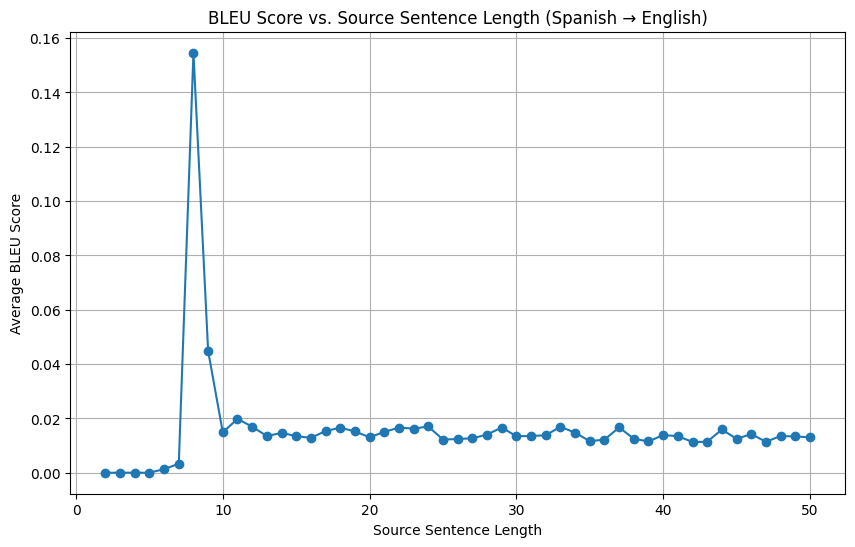

In [14]:
# Error Analysis: BLEU Score vs. Source Sentence Length

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from collections import defaultdict
import matplotlib.pyplot as plt

# Decode token IDs to text
def decode_ids(ids):
    return tokenizer.decode(ids, skip_special_tokens=True)

# Compute sentence-level BLEU scores and group by source length
def compute_bleu_by_length(model, loader):
    model.eval()
    smoothing = SmoothingFunction().method1
    length_bleu = defaultdict(list)

    with torch.no_grad():
        for src_ids, src_mask, tgt_ids in loader:
            src_ids, src_mask, tgt_ids = src_ids.to(DEVICE), src_mask.to(DEVICE), tgt_ids.to(DEVICE)
            hidden = model.encoder(src_ids, src_mask)

            batch_size = src_ids.size(0)
            preds = torch.full((batch_size, 1), tokenizer.cls_token_id, dtype=torch.long).to(DEVICE)

            for _ in range(tgt_ids.size(1) - 1):
                out, hidden = model.decoder(preds, hidden)
                next_token = out[:, -1, :].argmax(dim=-1, keepdim=True)
                preds = torch.cat([preds, next_token], dim=1)

            for i in range(batch_size):
                ref = decode_ids(tgt_ids[i])
                hyp = decode_ids(preds[i])
                ref_tokens = [ref.split()]
                hyp_tokens = hyp.split()
                bleu = sentence_bleu(ref_tokens, hyp_tokens, smoothing_function=smoothing)
                src_len = (src_mask[i] != 0).sum().item()
                length_bleu[src_len].append(bleu)

    return length_bleu

# Run analysis
length_bleu = compute_bleu_by_length(model, test_loader)
bucket_bleu = {length: sum(scores)/len(scores) for length, scores in length_bleu.items()}
sorted_lengths = sorted(bucket_bleu.keys())
avg_bleus = [bucket_bleu[l] for l in sorted_lengths]

# Plot
plt.figure(figsize=(10, 6))
plt.plot(sorted_lengths, avg_bleus, marker='o')
plt.xlabel("Source Sentence Length")
plt.ylabel("Average BLEU Score")
plt.title("BLEU Score vs. Source Sentence Length (Spanish → English)")
plt.grid(True)
plt.show()


In [ ]:
# Error Analysis: Df sorted by BLEU scores
# highest BLEU score of 1 only achieved if we translate empty commas or points: "." -> ".", e. g. 1957
# lowest BLEU scores of 0 for sentences that appeared probably only once. Model just outputs something completely different -> overfitting/ underfitting. Caused by us just using 10000 samples in the train set while having a relatively high model capacity

# scores of up x to 0.8 for easy translations like "Applause" or containing easy words like "Mr President" or "i would like top thank"
# short usually higher BLEU score
# i dont know if its an error in our pipeline but before every , there is a space

df_test[["en", "es", "pred_en", "bleu"]].sort_values(by="bleu", ascending=False)

,en,es,pred_en,bleu
18376,.,.,.,1.0
15530,.,.,.,1.0
15021,.,.,.,1.0
1957,.,.,.,1.0
5431,.,.,.,1.0
...,...,...,...,...
19056,Financial services policy (2005-2010) - White ...,Servicios financieros 2005-2010 (Libro Blanco)...,The Commission has also been able to relocate ...,0.0
9679,Customs 2000,«Aduana 2000»,The vote will take place tomorrow at 11 a . m .,0.0
123,de Lassus Saint Geniès report (A4-0027/99),Informe de Lassus Saint Geniès (A4-0027/99),The Commission has also been able to relocate ...,0.0
278,Subject: Irish county development plans,Asunto: Planes de desarrollo de los condados i...,The Commission has also been able to relocate ...,0.0


In [7]:
# Character-based Seq2Seq Model: Spanish → English

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from tqdm import tqdm

# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_CHAR_LEN = 100  # max number of characters per sentence (including sos/eos)
BATCH_SIZE = 16
EMBED_DIM = 128
HIDDEN_DIM = 768
DROPOUT = 0.1
NUM_EPOCHS = 10
LR = 3e-4
TEACHER_FORCING_RATIO = 0.5

# Special tokens
PAD = "<pad>"
SOS = "<sos>"
EOS = "<eos>"
UNK = "<unk>"

def build_char_vocab(sentences, min_freq=1):
    counter = Counter()
    for s in sentences:
        counter.update(list(s))
    # Keep characters with freq >= min_freq
    chars = [c for c, f in counter.items() if f >= min_freq]
    # Reserve special tokens at front
    idx2char = [PAD, SOS, EOS, UNK] + sorted(chars)
    char2idx = {c: i for i, c in enumerate(idx2char)}
    return char2idx, idx2char

def encode_char_sequence(s, char2idx, max_len):
    chars = list(s)
    seq = [char2idx.get(SOS)]  # start
    for c in chars:
        seq.append(char2idx.get(c, char2idx[UNK]))
        if len(seq) >= max_len - 1:  # reserve space for EOS
            break
    seq.append(char2idx.get(EOS))
    # pad
    if len(seq) < max_len:
        seq += [char2idx.get(PAD)] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
        if seq[-1] != char2idx[EOS]:
            seq[-1] = char2idx[EOS]
    return torch.tensor(seq, dtype=torch.long)

class CharTranslationDataset(Dataset):
    def __init__(self, df_src, df_tgt, src_char2idx, tgt_char2idx, max_len):
        self.src_sentences = df_src.tolist()  # Spanish
        self.tgt_sentences = df_tgt.tolist()  # English
        self.src_char2idx = src_char2idx
        self.tgt_char2idx = tgt_char2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.src_sentences)

    def __getitem__(self, idx):
        src = self.src_sentences[idx]
        tgt = self.tgt_sentences[idx]
        src_seq = encode_char_sequence(src, self.src_char2idx, self.max_len)
        tgt_seq = encode_char_sequence(tgt, self.tgt_char2idx, self.max_len)
        return src_seq, tgt_seq

def collate_fn(batch):
    src_seqs, tgt_seqs = zip(*batch)
    src = torch.stack(src_seqs)
    tgt = torch.stack(tgt_seqs)
    return src, tgt

# Build vocabularies from training splits
src_sentences_train = df_train["es"].tolist()
tgt_sentences_train = df_train["en"].tolist()
src_char2idx, src_idx2char = build_char_vocab(src_sentences_train)
tgt_char2idx, tgt_idx2char = build_char_vocab(tgt_sentences_train)

SRC_VOCAB_SIZE = len(src_idx2char)
TGT_VOCAB_SIZE = len(tgt_idx2char)

# Encoder: character-level GRU
class Encoder(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embed_dim, padding_idx=src_char2idx[PAD])
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: [B, L]
        embedded = self.dropout(self.embedding(src))  # [B, L, E]
        outputs, hidden = self.rnn(embedded)  # hidden: [1, B, H]
        return hidden  # return last hidden

# Decoder: character-level GRU with simple output projection
class Decoder(nn.Module):
    def __init__(self, output_dim, embed_dim, hidden_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, embed_dim, padding_idx=tgt_char2idx[PAD])
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_char, hidden):
        # input_char: [B] (current timestep input)
        input_char = input_char.unsqueeze(1)  # [B,1]
        embedded = self.dropout(self.embedding(input_char))  # [B,1,E]
        output, hidden = self.rnn(embedded, hidden)  # output: [B,1,H]
        pred = self.fc_out(output.squeeze(1))  # [B, output_dim]
        return pred, hidden

# Seq2Seq wrapper with teacher forcing
class Seq2SeqChar(nn.Module):
    def __init__(self, encoder, decoder, tgt_sos_idx, tgt_eos_idx, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.tgt_sos_idx = tgt_sos_idx
        self.tgt_eos_idx = tgt_eos_idx
        self.device = device

    def forward(self, src, tgt=None, teacher_forcing_ratio=0.5):
        # src: [B, L], tgt: [B, L]
        batch_size = src.size(0)
        max_len = tgt.size(1) if tgt is not None else MAX_CHAR_LEN
        outputs = torch.zeros(batch_size, max_len, TGT_VOCAB_SIZE, device=self.device)

        hidden = self.encoder(src)  # [1, B, H]
        input_char = torch.full((batch_size,), self.tgt_sos_idx, dtype=torch.long, device=self.device)

        for t in range(0, max_len):
            pred, hidden = self.decoder(input_char, hidden)  # pred: [B, V]
            outputs[:, t, :] = pred
            use_teacher = (tgt is not None) and (torch.rand(1).item() < teacher_forcing_ratio)
            if use_teacher:
                input_char = tgt[:, t]  # teacher forcing
            else:
                input_char = pred.argmax(1)
        return outputs  # [B, L, V]

# Instantiate datasets/loaders
train_ds_char = CharTranslationDataset(df_train["es"], df_train["en"], src_char2idx, tgt_char2idx, MAX_CHAR_LEN)
val_ds_char = CharTranslationDataset(df_val["es"], df_val["en"], src_char2idx, tgt_char2idx, MAX_CHAR_LEN)
test_ds_char = CharTranslationDataset(df_test["es"], df_test["en"], src_char2idx, tgt_char2idx, MAX_CHAR_LEN)

train_loader = DataLoader(train_ds_char, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds_char, batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(test_ds_char, batch_size=BATCH_SIZE, collate_fn=collate_fn)

# Model instantiation
encoder = Encoder(SRC_VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, DROPOUT)
decoder = Decoder(TGT_VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, DROPOUT)
model = Seq2SeqChar(encoder, decoder, tgt_sos_idx=tgt_char2idx[SOS], tgt_eos_idx=tgt_char2idx[EOS], device=DEVICE).to(DEVICE)

# Loss & optimizer
criterion = nn.CrossEntropyLoss(ignore_index=tgt_char2idx[PAD])
optimizer = optim.Adam(model.parameters(), lr=LR)

# Training / evaluation loops
def train_epoch(model, loader):
    model.train()
    epoch_loss = 0
    for src, tgt in tqdm(loader, desc="Train"):
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)
        optimizer.zero_grad()
        output = model(src, tgt, teacher_forcing_ratio=TEACHER_FORCING_RATIO)
        # shift targets: we want to predict t-th char using input t (since tgt includes SOS at 0)
        output_flat = output.reshape(-1, TGT_VOCAB_SIZE)
        tgt_flat = tgt.reshape(-1)
        loss = criterion(output_flat, tgt_flat)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(loader)

def eval_epoch(model, loader):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src = src.to(DEVICE)
            tgt = tgt.to(DEVICE)
            output = model(src, tgt, teacher_forcing_ratio=0.0)  # no teacher forcing in eval
            loss = criterion(output.reshape(-1, TGT_VOCAB_SIZE), tgt.reshape(-1))
            epoch_loss += loss.item()
    return epoch_loss / len(loader)

# Run training
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader)
    val_loss = eval_epoch(model, val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Final test eval
test_loss = eval_epoch(model, test_loader)
print(f"\nTest Loss: {test_loss:.4f}")

# (Optional) Greedy inference helper
def translate_sentence_char(src_sentence, src_char2idx, tgt_idx2char, model, max_len=MAX_CHAR_LEN):
    model.eval()
    with torch.no_grad():
        src_seq = encode_char_sequence(src_sentence, src_char2idx, max_len).unsqueeze(0).to(DEVICE)  # [1,L]
        output = model(src_seq, tgt=None, teacher_forcing_ratio=0.0)  # [1,L,V]
        preds = output.argmax(-1).squeeze(0)  # [L]
        # decode until EOS
        result_chars = []
        for idx in preds:
            char = tgt_idx2char[idx.item()]
            if char == EOS:
                break
            if char not in {PAD, SOS}:
                result_chars.append(char)
        return "".join(result_chars)

Train: 100%|██████████| 860/860 [01:05<00:00, 13.20it/s]


Epoch 1 | Train Loss: 2.6836 | Val Loss: 3.2342


Train: 100%|██████████| 860/860 [01:04<00:00, 13.26it/s]


Epoch 2 | Train Loss: 2.4580 | Val Loss: 3.3857


Train: 100%|██████████| 860/860 [01:04<00:00, 13.39it/s]


...

Epoch 8 | Train Loss: 2.2075 | Val Loss: 3.3273


Train: 100%|██████████| 860/860 [01:04<00:00, 13.39it/s]


Epoch 9 | Train Loss: 2.1895 | Val Loss: 3.2592


Train: 100%|██████████| 860/860 [01:04<00:00, 13.41it/s]


Epoch 10 | Train Loss: 2.1653 | Val Loss: 3.4308

Test Loss: 3.4338


In [9]:
# Average BLEU score for character-level model (worse)

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Helpers: reference and hypothesis processing
def char_tokenize(s, keep_spaces=True):
    if not keep_spaces:
        s = s.replace(" ", "")
    return list(s.lower())

def word_tokenize_from_char_output(s):
    # simple whitespace split; you can refine (e.g., punctuation handling) if needed
    return s.lower().strip().split()

# Generate translations (greedy) from the char model
predictions_char = []
for sent in tqdm(df_test["es"], desc="Char-model translating"):
    pred = translate_sentence_char(
        src_sentence=sent,
        src_char2idx=src_char2idx,
        tgt_idx2char=tgt_idx2char,
        model=model,
        max_len=MAX_CHAR_LEN,
    )
    predictions_char.append(pred)

df_test["pred_en_char"] = predictions_char

# Compute BLEU scores
smoothie = SmoothingFunction().method4

char_bleu_scores = []
word_bleu_scores = []

for ref, hyp in zip(df_test["en"], df_test["pred_en_char"]):
    # Character-level BLEU (e.g., include spaces)
    ref_chars = char_tokenize(ref, keep_spaces=True)
    hyp_chars = char_tokenize(hyp, keep_spaces=True)
    cb_score = sentence_bleu([ref_chars], hyp_chars, weights=(0.25, 0.25, 0.25, 0.25),
                             smoothing_function=smoothie)
    char_bleu_scores.append(cb_score)

    # Word-level BLEU (from the character output)
    ref_words = word_tokenize_from_char_output(ref)
    hyp_words = word_tokenize_from_char_output(hyp)
    # you can choose weights like (0.5,0.5) for bigram-ish or full 4-gram:
    wb_score = sentence_bleu([ref_words], hyp_words, weights=(0.25, 0.25, 0.25, 0.25),
                             smoothing_function=smoothie)
    word_bleu_scores.append(wb_score)

df_test["bleu_char"] = char_bleu_scores
df_test["bleu_word_from_char"] = word_bleu_scores

avg_char_bleu = sum(char_bleu_scores) / len(char_bleu_scores)
avg_word_bleu = sum(word_bleu_scores) / len(word_bleu_scores)

print(f"Average character-level BLEU: {avg_char_bleu:.4f}")
print(f"Average word-level BLEU (from char output): {avg_word_bleu:.4f}")

Char-model translating: 100%|██████████| 3932/3932 [01:20<00:00, 48.80it/s]


Average character-level BLEU: 0.1572
Average word-level BLEU (from char output): 0.0256
